# PREVISIONE QUALITÀ DELL'ARIA
Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione

### 1.1 Obiettivo

L'obiettivo di questo progetto è di prevedere la concentrazione oraria di **PM2.5** (µg/m³) nell'area metropolitana di Pechino a partire da variabili meteorologiche, temporali e altri inquinanti atmosferici.

Il PM2.5 è particolato fine con diametro inferiore a 2.5 µm, abbastanza piccolo da penetrare nei polmoni e nel sangue. L'OMS raccomanda un limite di 15 µg/m³ per la media giornaliera. Pechino nel periodo 2013–2017 superava regolarmente questa soglia, con picchi oltre i 500 µg/m³.

Un modello accurato di previsione del PM2.5 ha applicazioni concrete: sistemi di allerta precoce per la popolazione, supporto alla pianificazione di politiche ambientali, e valutazione della possibilità di stimare l'inquinamento usando solo dati meteo.

Questo tema è rilevante anche nel contesto italiano: la Pianura Padana è tra le zone peggiori d'Europa per PM2.5.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42

### 1.2 Importazione del dataset

I dataset utilizzati sono stati ottenuti da [**Beijing Multi-Site Air-Quality Data**](https://doi.org/10.24432/C5RK5G). Contengono misurazioni orarie da 12 stazioni di monitoraggio di Pechino nel periodo marzo 2013 – febbraio 2017.

Le feature si suddividono in quattro categorie:

**Temporali:** `year`, `month`, `day`, `hour`.

**Inquinanti** (µg/m³):
- `PM2.5`: particolato fine, target della previsione
- `PM10`: particolato grossolano, spesso co-emesso con il PM2.5
- `SO2`: biossido di zolfo, da combustione di carbone
- `NO2`: biossido di azoto, da traffico e centrali termiche
- `CO`: monossido di carbonio, indicatore di combustione incompleta
- `O3`: ozono, inquinante secondario con comportamento opposto agli altri (alto quando PM2.5 è basso)

**Meteorologiche:**
- `TEMP` (°C), `PRES` (hPa), `DEWP` (°C), `RAIN` (mm), `WSPM` (m/s)
- `wd`: direzione del vento (categorica)

**Metadati:** `station`: nome della stazione di monitoraggio.

In [3]:
directory = "datasets"
dfs = []
for nome_file in os.listdir(directory):
    if nome_file.endswith(".csv"):
        dfs.append(pd.read_csv(os.path.join(directory, nome_file), index_col=False))

df = pd.concat(dfs, ignore_index=True)

if 'No' in df.columns:
    df = df.drop(columns=['No'])

df.info(verbose=False, memory_usage='deep')
df.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Columns: 17 entries, year to station
dtypes: float64(11), int64(4), str(2)
memory usage: 91.7 MB


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng


La colonna `No` (identificatore) viene rimossa in fase di caricamento perché non informativa.

## 2. Analisi esplorativa dei dati

### 2.1 Statistiche generali

In [4]:
df.describe().round(2)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


Il PM2.5 medio è circa 80 µg/m³ con una deviazione standard di ~81, segnale di una distribuzione molto dispersa. Il massimo raggiunge 999 µg/m³, un valore estremo che potrebbe indicare un evento eccezionale o un'anomalia del sensore. Gli altri inquinanti (PM10, SO2, NO2, CO) mostrano un pattern simile con concentrazione a sinistra. Le variabili meteorologiche hanno range coerenti con il clima continentale di Pechino.

In [5]:
nan_counts = df.isnull().sum()
nan_percentages = (nan_counts / len(df) * 100).round(2)

nan_summary = pd.DataFrame({
    '# NaN': nan_counts,
    '% NaN': nan_percentages
}).sort_values('% NaN', ascending=False)

nan_summary = nan_summary[nan_summary['# NaN'] > 0]
nan_summary

,# NaN,% NaN
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
RAIN,390,0.09
TEMP,398,0.09


Si osserva che le variabili temporali (year, month, day, hour) e station non hanno valori mancanti.
Gli inquinanti, invece, presentano la percentuale più alta di NaN, probabilmente per malfunzionamenti dei sensori.
Le variabili meteorologiche sono quasi complete: TEMP, PRES, DEWP, RAIN e WSPM.

In ogni caso la percentuale di NaN rimane contenuta per tutte le colonne, rendendo il dataset complessivamente affidabile. I valori mancanti verranno gestiti nella fase di preparazione dei dati (sezione 3).

### 2.2 Distribuzione del target (PM2.5)

Media: 79.8 µg/m³
Mediana: 55.0 µg/m³
Std: 80.8
Min: 2
Max: 999
Ore con aria buona (≤35): 37.3%
Ore con livelli dannosi (>115): 23.6%


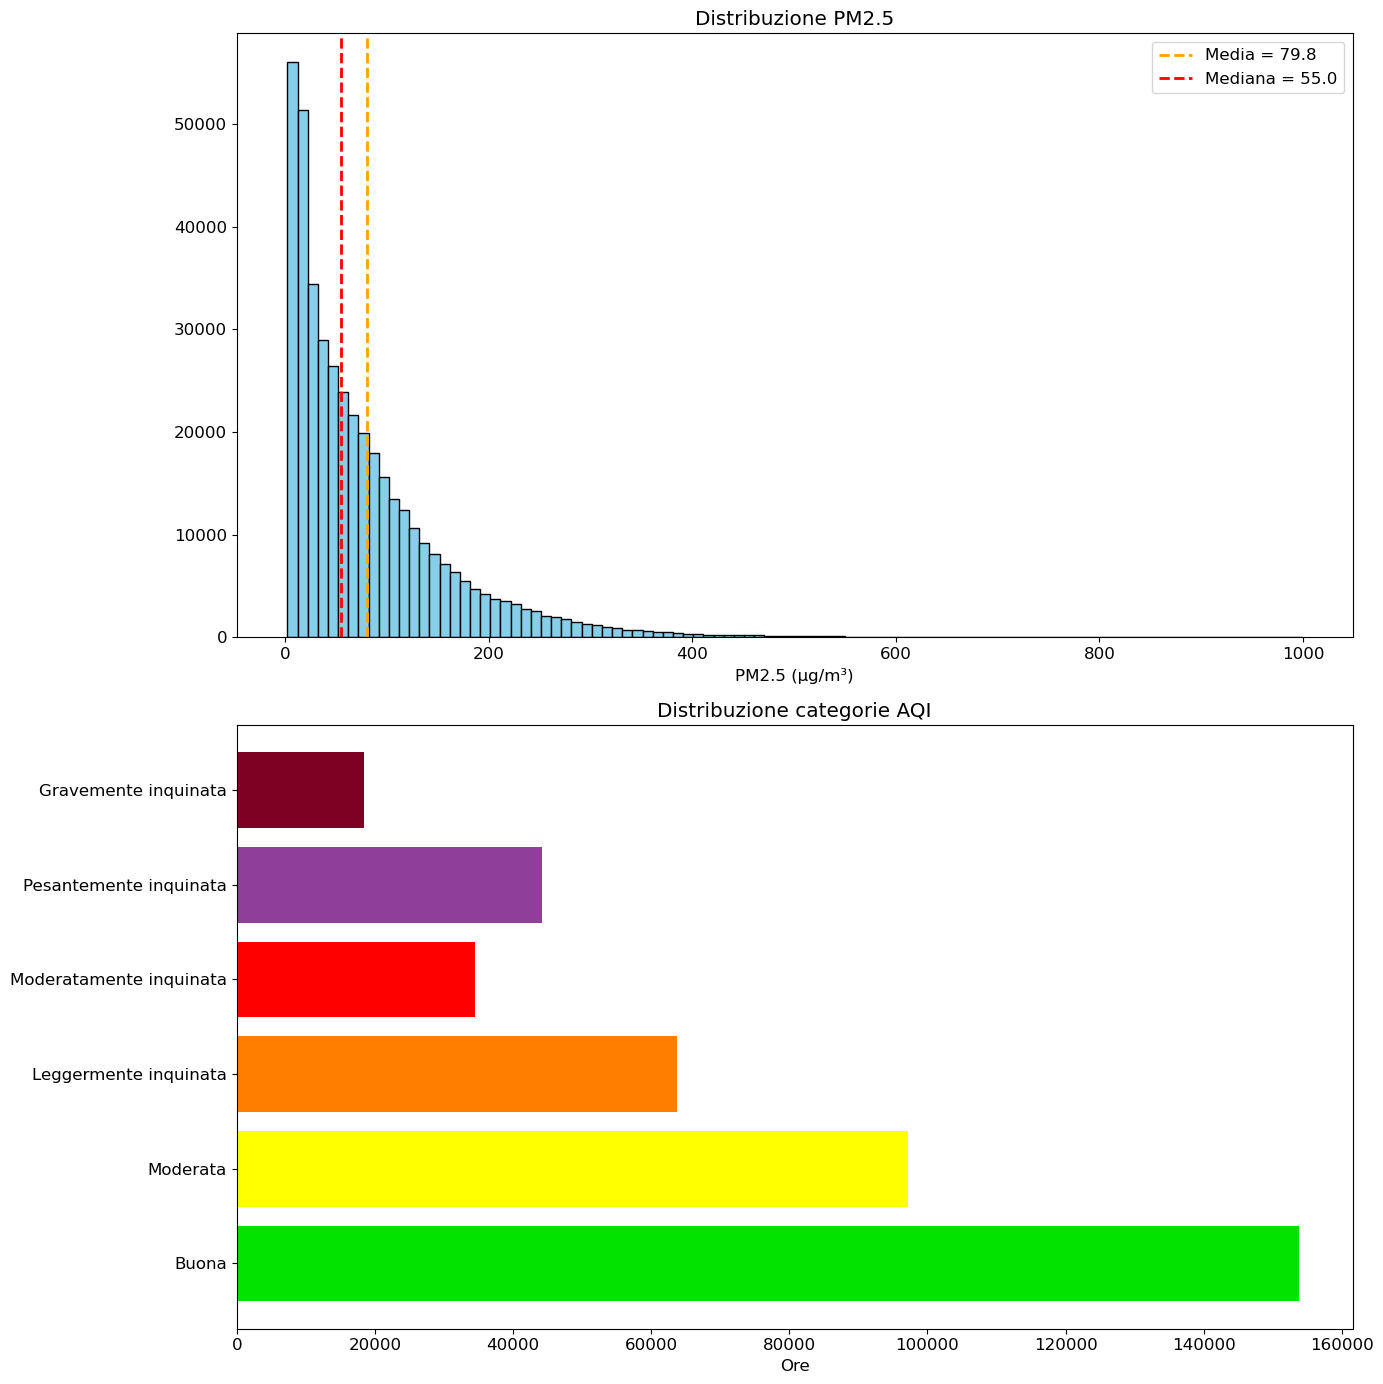

In [6]:
pm25 = df['PM2.5'].dropna()

mean_val = pm25.mean()
median_val = pm25.median()

# Fasce di qualità dell'aria
aqi_labels = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]

aqi_cat = pd.cut(pm25, bins=aqi_bins, labels=aqi_labels, include_lowest=True)
aqi_counts = aqi_cat.value_counts().reindex(aqi_labels)

# Figura
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Istogramma
axes[0].hist(pm25, bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Media = {mean_val:.1f}')
axes[0].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Mediana = {median_val:.1f}')
axes[0].set_title('Distribuzione PM2.5')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].legend()

# Categorie AQI
axes[1].barh(aqi_counts.index, aqi_counts.values, color=aqi_colors)
axes[1].set_title('Distribuzione categorie AQI')
axes[1].set_xlabel('Ore')

# Statistiche
pct_buona = (pm25 <= 35).sum() / len(pm25) * 100
pct_insalubre = (pm25 > 115).sum() / len(pm25) * 100

print(f"Media: {mean_val:.1f} µg/m³\nMediana: {median_val:.1f} µg/m³")
print(f"Std: {pm25.std():.1f}")
print(f"Min: {pm25.min():.0f}\nMax: {pm25.max():.0f}")
print(f"Ore con aria buona (≤35): {pct_buona:.1f}%")
print(f"Ore con livelli dannosi (>115): {pct_insalubre:.1f}%")

plt.tight_layout()
plt.show()

La distribuzione del PM2.5 è molto asimmetrica: la maggior parte delle ore ha valori tra 0 e 100 µg/m³, ma la coda destra si estende fino a 999. La media (~80) è molto superiore alla mediana (~55), a conferma che i valori estremi trascinano la media verso l'alto. Solo circa il 37% delle ore ha aria "buona" (≤35 µg/m³) secondo lo standard cinese, mentre circa il 24% rientra nelle categorie con livelli dannosi.

### 2.3 Analisi temporale

In [7]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['weekday'] = df['datetime'].dt.dayofweek

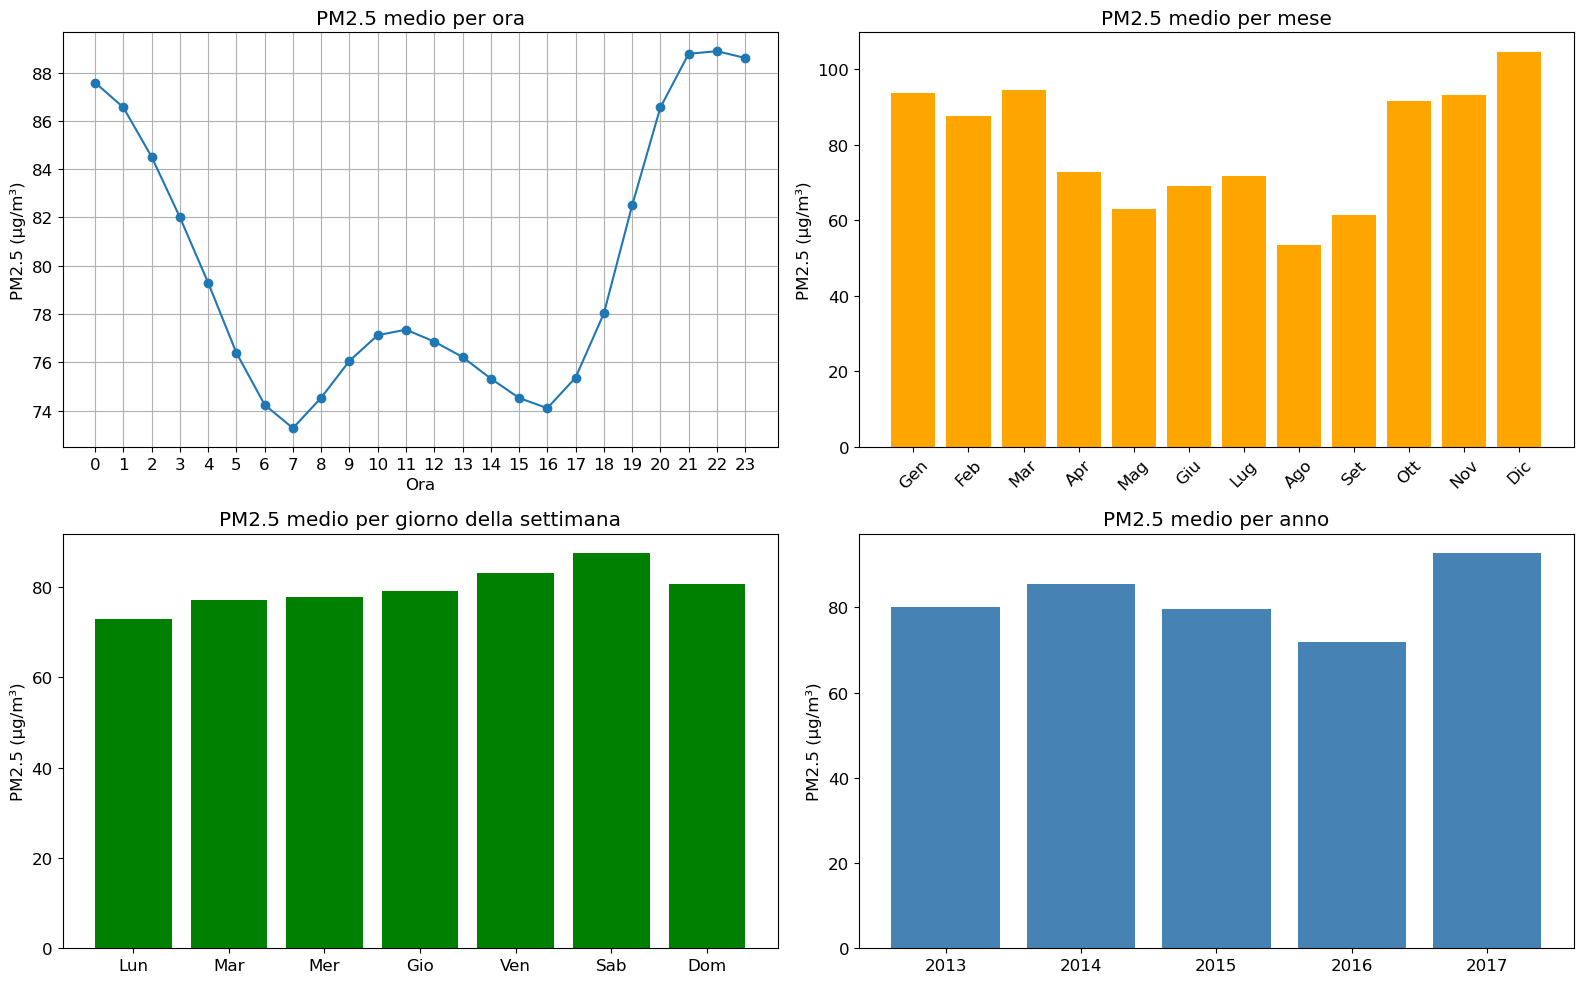

In [8]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()
monthly_pm25 = df.groupby('month')['PM2.5'].mean()

mesi = ['Gen','Feb','Mar','Apr','Mag','Giu', 'Lug','Ago','Set','Ott','Nov','Dic']

weekday_map = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Gio', 4:'Ven', 5:'Sab', 6:'Dom'}
weekday_pm25 = df.groupby('weekday')['PM2.5'].mean().rename(index=weekday_map)

yearly_pm25 = df.groupby('year')['PM2.5'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orario
axes[0,0].plot(hourly_pm25.index, hourly_pm25.values, marker='o')
axes[0,0].set_title('PM2.5 medio per ora')
axes[0,0].set_xlabel('Ora')
axes[0,0].set_ylabel('PM2.5 (µg/m³)')
axes[0,0].set_xticks(range(24))
axes[0,0].grid(True)

# Mensile
axes[0,1].bar(mesi, monthly_pm25.values, color='orange')
axes[0,1].set_title('PM2.5 medio per mese')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')
axes[0,1].tick_params(axis='x', rotation=45)

# Settimanale
axes[1,0].bar(weekday_pm25.index, weekday_pm25.values, color='green')
axes[1,0].set_title('PM2.5 medio per giorno della settimana')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')

# Annuale
axes[1,1].bar(yearly_pm25.index.astype(str), yearly_pm25.values, color='steelblue')
axes[1,1].set_title('PM2.5 medio per anno')
axes[1,1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

**Orario**: i livelli massimi si registrano durante la notte (18:00–04:00), con un minimo la mattina (6:00–08:00) e nel primo pomeriggio (14:00–17:00).

**Stagionale**: i mesi invernali (Nov–Feb) mostrano valori molto più alti dell'estate (Giu–Ago).

**Settimanale**: le differenze tra giorni feriali e weekend sono minime (questo suggerisce che il traffico veicolare non è il driver principale del PM2.5 a Pechino, a differenza di quanto ci si potrebbe aspettare, il riscaldamento e le condizioni meteo dominano).

**Annuale**: si osserva un lieve miglioramento nel tempo, coerente con le politiche anti-inquinamento adottate.

In conclusione, le variabili temporali, soprattutto ora e mese, saranno feature importanti per la predizione del PM2.5.

### 2.4 PM2.5 medio per ora e mese

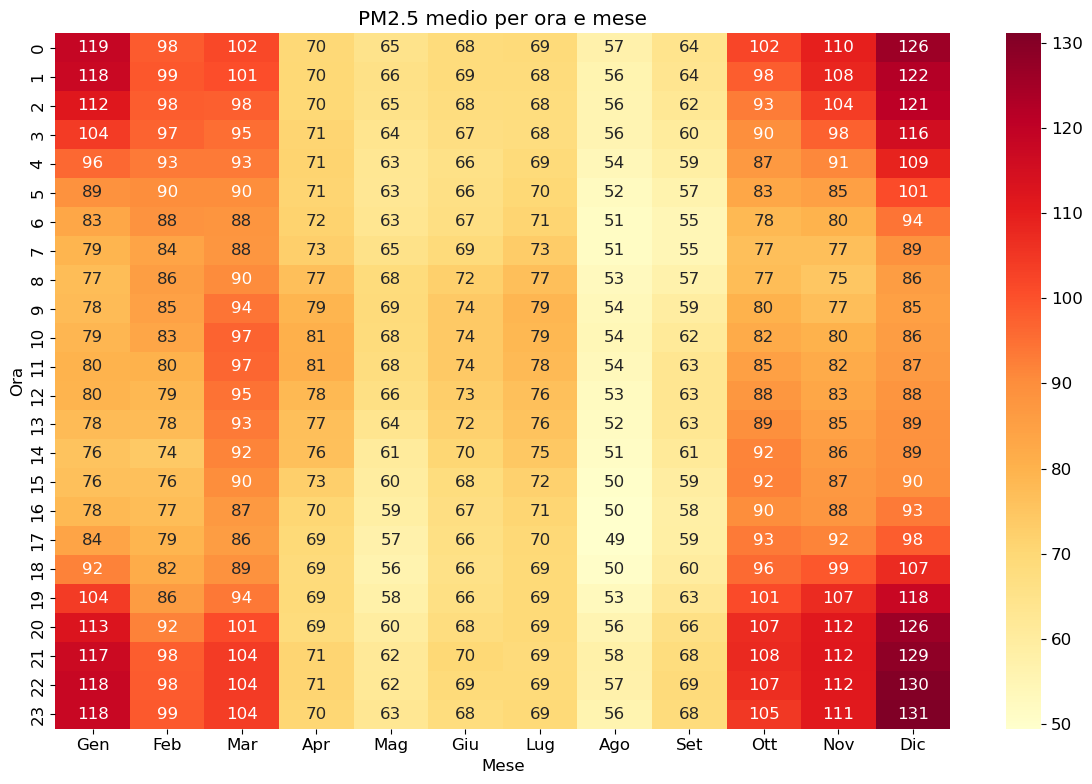

In [9]:
pivot = df.pivot_table(
    values='PM2.5',
    index='hour',    # righe
    columns='month', # colonne
    aggfunc='mean'   # ogni cella contiene la media
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', xticklabels=mesi, yticklabels=range(24))
plt.title('PM2.5 medio per ora e mese')
plt.xlabel('Mese')
plt.ylabel('Ora')
plt.tight_layout()
plt.show()

I mesi invernali (novembre–febbraio) mostrano i valori più elevati in tutte le fasce orarie, a causa del riscaldamento domestico e delle inversioni termiche più frequenti, mentre i mesi estivi (giugno–agosto) presentano i valori più bassi.

Sul piano giornaliero si osserva un picco serale/notturno (tra le 18:00 e le 04:00) e un minimo nel primo pomeriggio (13:00–16:00). La combinazione peggiore è quindi nelle notti invernali, dove i due fattori si sommano.

### 2.5 Distribuzione variabili meteorologiche

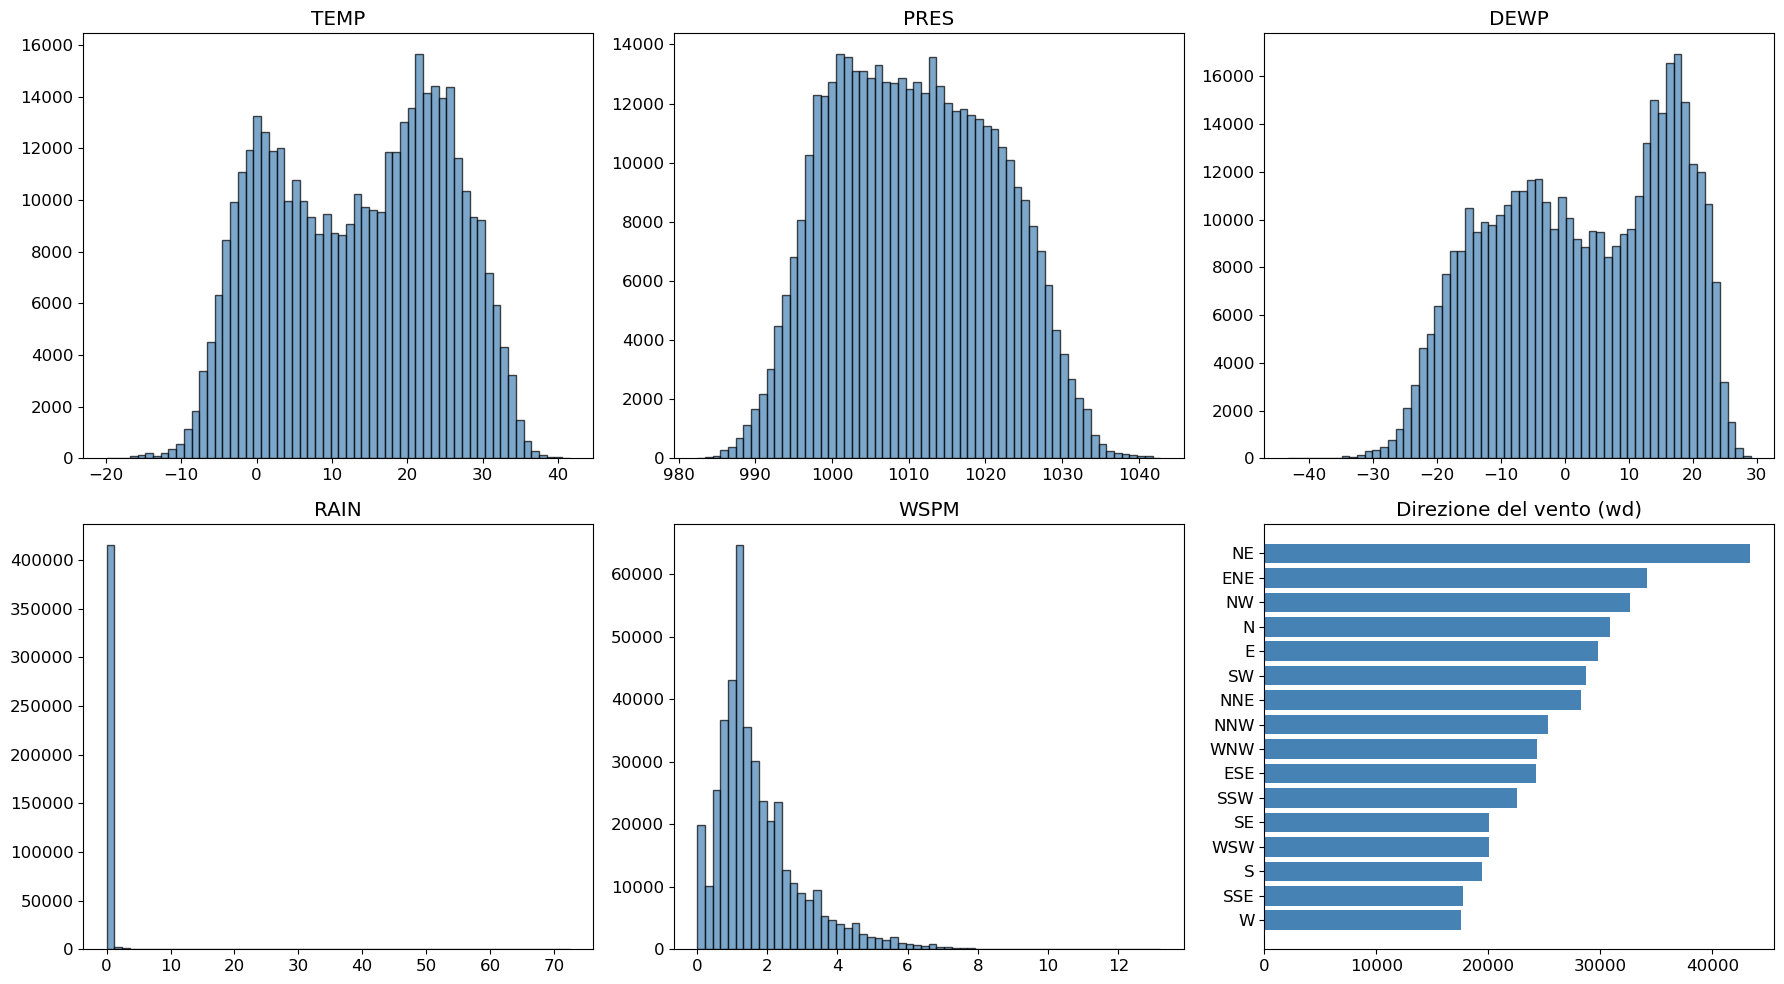

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

meteo_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for ax, var in zip(axes.flat[:5], meteo_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(var)

# Direzione del vento
wd_counts = df['wd'].value_counts().sort_values(ascending=True)
axes[1,2].barh(wd_counts.index, wd_counts.values, color='steelblue')
axes[1,2].set_title('Direzione del vento (wd)')

plt.tight_layout()
plt.show()

TEMP ha un range di circa 60°C (da -20 a +40). PRES mostra una distribuzione bimodale legata alla variazione stagionale. RAIN è quasi esclusivamente a 0: la stragrande maggioranza delle ore ha precipitazione zero. WSPM è concentrato a sinistra, con prevalenza di vento debole. La direzione del vento dominante è NW.

### 2.6 Distribuzione altri inquinanti

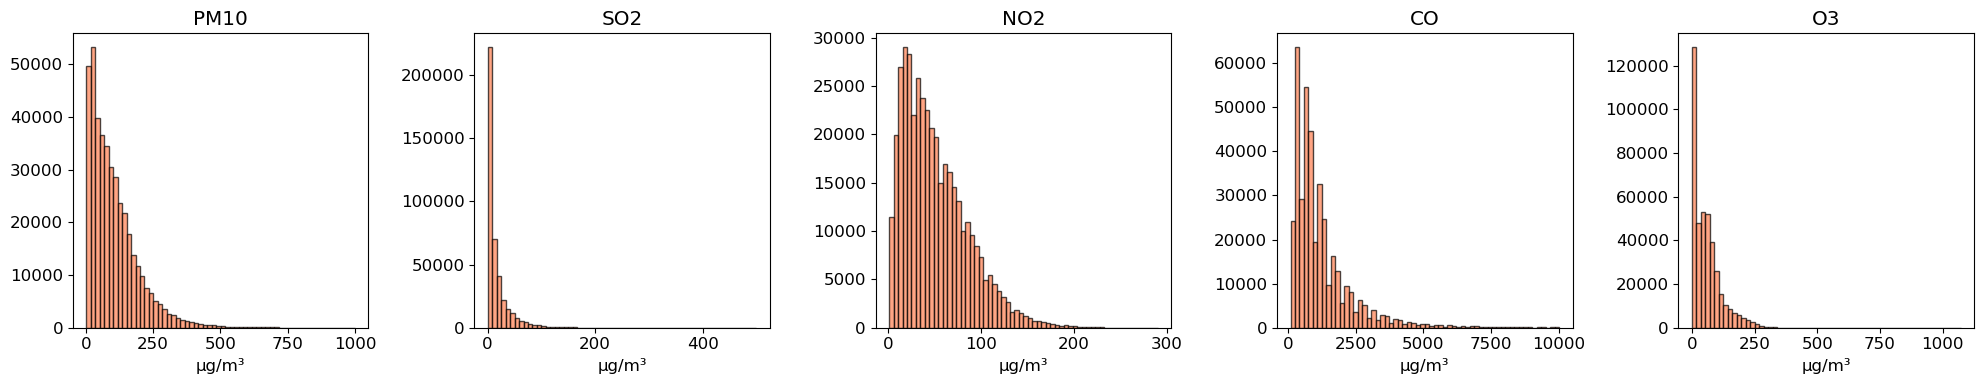

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

poll_vars = ['PM10', 'SO2', 'NO2', 'CO', 'O3']

for ax, var in zip(axes, poll_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='coral', edgecolor='black', alpha=0.7)
    ax.set_title(var)
    ax.set_xlabel('µg/m³')

plt.tight_layout()
plt.show()

Tutti gli inquinanti primari (PM10, SO2, NO2, CO) sono concentrati a sinistra come il PM2.5, coerente con il fatto che derivano dalle stesse fonti di emissione (combustione di carbone, traffico, attività industriali). O3 invece è un inquinante **secondario** e ha un comportamento opposto agli altri, i suoi livelli sono alti quando il PM2.5 è basso (giornate soleggiate e ventilate) e viceversa. Questa anticorrelazione sarà visibile nella matrice di correlazione.

### 2.7 Analisi per stazione

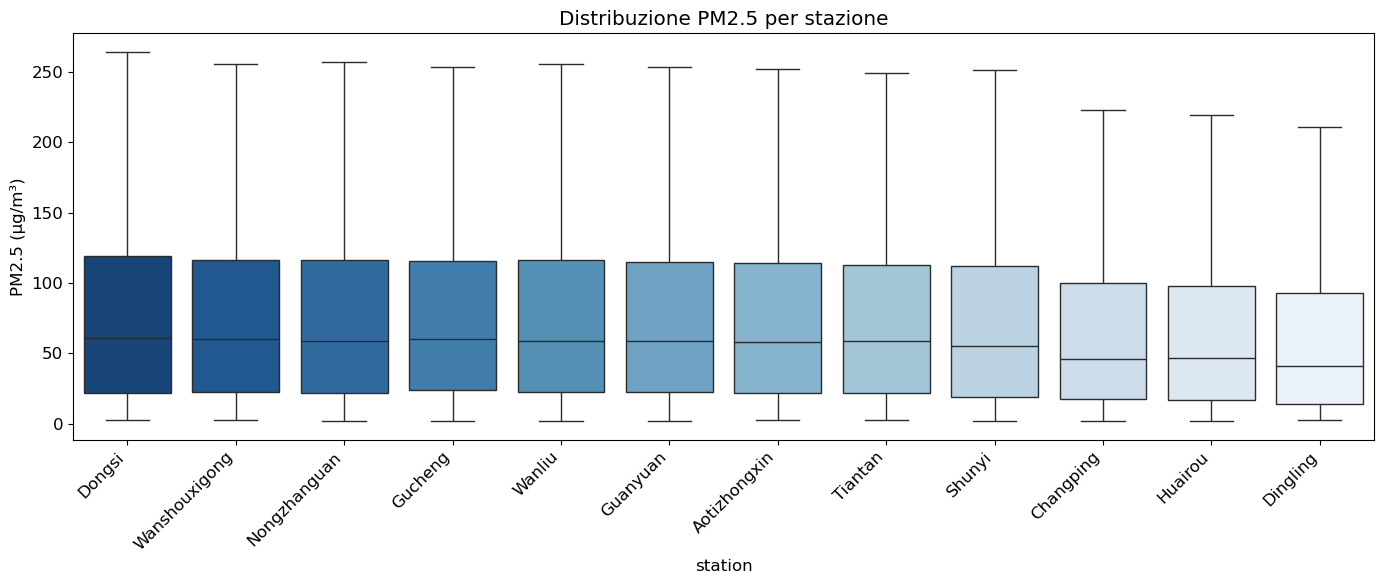

,mean,median,std,count
station,,,,
Dongsi,86.2,61.0,86.6,34314
Wanshouxigong,85.0,60.0,86.0,34368
Nongzhanguan,84.8,59.0,86.2,34436
Gucheng,83.9,60.0,82.8,34418
Wanliu,83.4,59.0,81.9,34682
Guanyuan,82.9,59.0,80.9,34448
Aotizhongxin,82.8,58.0,82.1,34139
Tiantan,82.2,59.0,80.9,34387
Shunyi,79.5,55.0,81.2,34151


In [12]:
station_stats = (
    df.groupby('station')['PM2.5']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .round(1)
)

station_order = station_stats.index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df, x='station', y='PM2.5',
    order=station_order, palette='Blues_r',
    showfliers=False
)
plt.title('Distribuzione PM2.5 per stazione')
plt.ylabel('PM2.5 (µg/m³)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

station_stats

Le stazioni hanno valori medi molto simili tra loro: l'inquinamento da PM2.5 è distribuito in modo relativamente uniforme su scala urbana a Pechino. Questo indica che la stazione di rilevamento non sarà un predittore importante.

### 2.8 Correlazione tra le feature

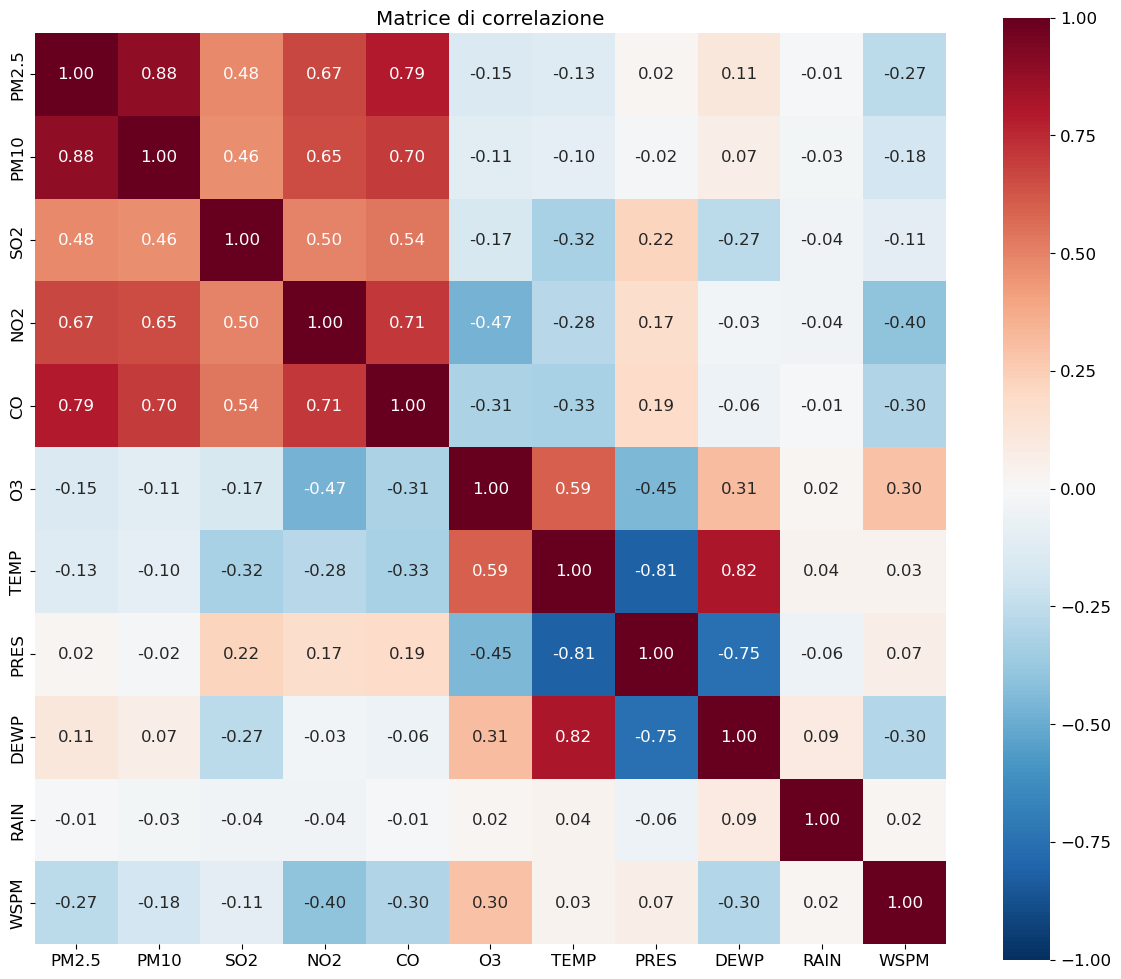

In [13]:
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', square=True, center=0, vmin=-1, vmax=1)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

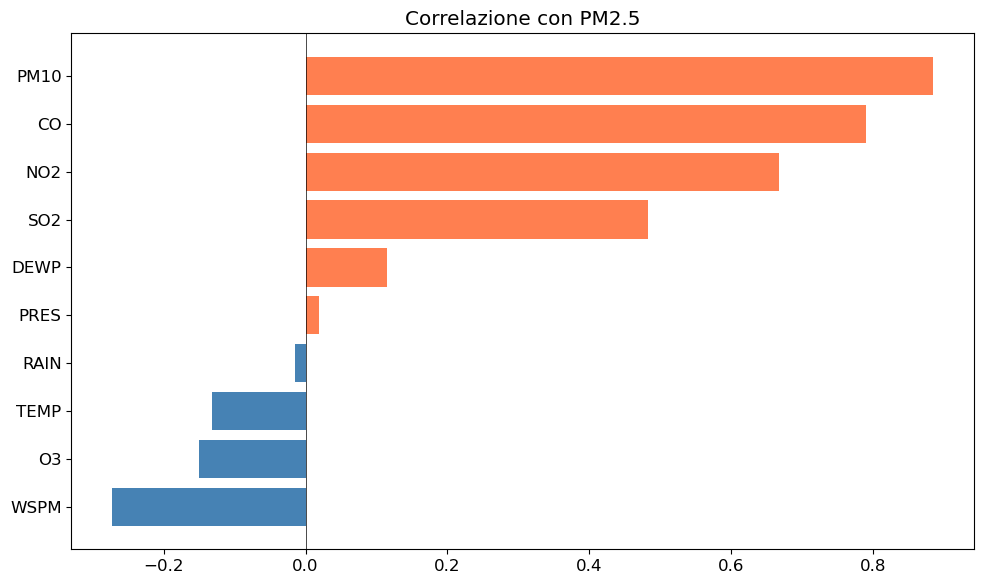

In [14]:
corr_pm25 = corr['PM2.5'].drop('PM2.5').sort_values()

colors = ['steelblue' if v < 0 else 'coral' for v in corr_pm25.values]

plt.figure(figsize=(10, 6))
plt.barh(corr_pm25.index, corr_pm25.values, color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Correlazione con PM2.5')
plt.tight_layout()
plt.show()

Le correlazioni più forti con il PM2.5 sono:

- **CO e PM10** (> 0.7): stesse fonti di emissione, co-emessi con il PM2.5.
- **NO2 e SO2**: correlazione positiva.
- **O3**: correlazione negativa.
- **WSPM**: negativa, il vento disperde il particolato.
- **TEMP**: negativa, in inverno convergono riscaldamento a carbone e inversioni termiche.

### 2.9 Distribuzione di PM2.5 rispetto alle variabili predittive

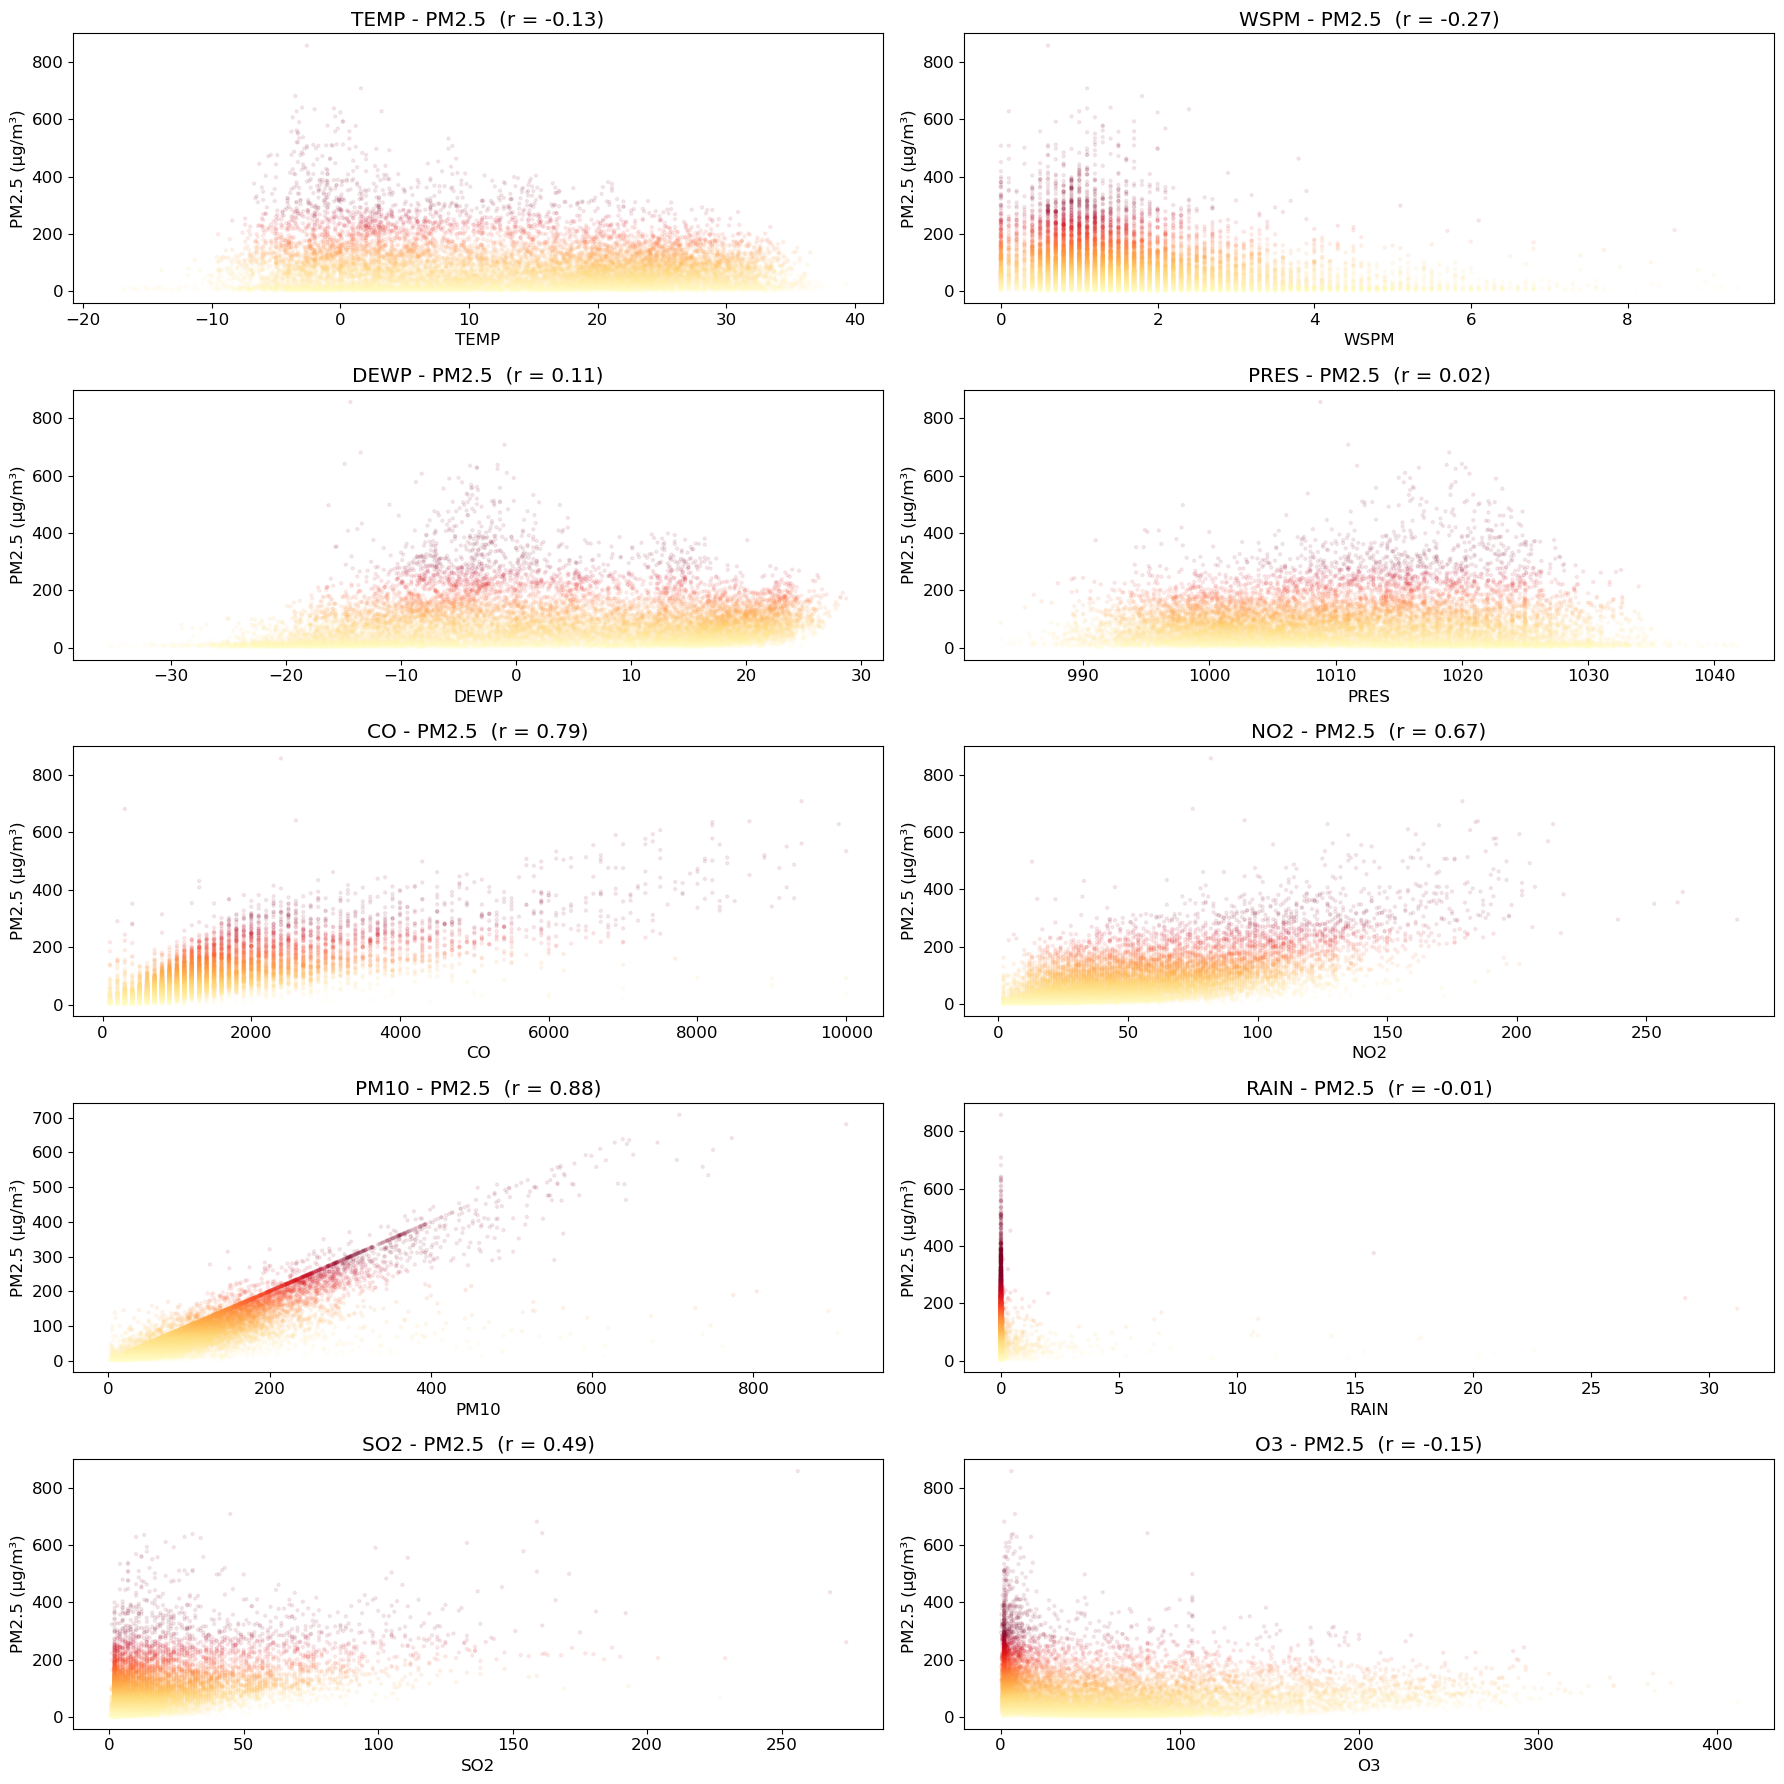

In [15]:
sample = df.dropna(subset=['PM2.5']).sample(n=15000, random_state=42)

scatter_vars = ['TEMP', 'WSPM', 'DEWP', 'PRES', 'CO', 'NO2', "PM10", "RAIN", "SO2", "O3"]

fig, axes = plt.subplots(5, 2, figsize=(18, 18))

for ax, var in zip(axes.flat, scatter_vars):
    r = sample[['PM2.5', var]].corr().iloc[0, 1]
    sc = ax.scatter(sample[var], sample['PM2.5'], c=sample['PM2.5'], cmap='YlOrRd', alpha=0.08, s=5, vmax=300)
    ax.set_xlabel(var)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{var} - PM2.5  (r = {r:.2f})')

plt.tight_layout()
plt.show()

Tra gli inquinanti, PM10 risulta il predittore più forte con una correlazione di 0.88: la relazione è quasi lineare, a conferma che i due particolati condividono le stesse sorgenti di emissione. L'ozono invece mostra una correlazione negativa (-0.15), poiché essendo un inquinante secondario che si forma con la luce solare tende ad essere elevato proprio quando il PM2.5 è basso, ovvero in estate.

Per le feature meteorologiche, la velocità del vento è la variabile più rilevante (-0.27): venti forti favoriscono la dispersione del particolato. La temperatura (-0.14) riflette l'effetto stagionale dei sistemi di riscaldamento, mentre pressione (0.04) e pioggia (-0.02) mostrano correlazioni trascurabili, probabilmente perché il loro effetto sul PM2.5 è indiretto.

### 2.10 Conclusioni dell'analisi esplorativa

- PM2.5 ha una distribuzione molto asimmetrica con picchi estremi.
- Pattern temporali chiari (orari, stagionali, annuali) che motivano le feature cicliche.
- CO, PM10, NO2 sono fortemente correlati al target (stesse fonti di emissione).
- Le variabili meteo (vento, temperatura, pressione) hanno correlazioni significative.
- Le stazioni mostrano livelli medi simili.

Queste osservazioni sono fondamentali per le scelte di preprocessing: codifica ciclica per le variabili temporali e la direzione del vento, esclusione di PM10 per l'altissima correlazione con il target, e split temporale per rispettare la struttura sequenziale dei dati.

## 3. Preparazione dei dati

### 3.1 Gestione valori mancanti

I NaN sono causati da guasti dei sensori e rappresentano meno del 5% dei dati. Data la bassa percentuale, si rimuovono direttamente le righe con valori mancanti.

In [16]:
df_model = df.copy()
df_model = df_model.dropna()
print(f"Righe dopo la rimozione dei NaN: {len(df_model):,}")

Righe dopo la rimozione dei NaN: 382,168


### 3.2 Codifica ciclica

Diverse variabili nel dataset sono cicliche: l'ora del giorno, il mese, il giorno della settimana e la direzione del vento. La codifica numerica grezza non rispetta questa periodicità. La trasformazione sin/cos risolve il problema, mappando ogni valore su un cerchio dove gli estremi sono adiacenti.
Si estrae anche un flag binario per il weekend.

In [17]:
# Giorno della settimana e weekend
df_model['dayofweek'] = df_model['datetime'].dt.dayofweek
df_model['is_weekend'] = (df_model['dayofweek'] >= 5).astype(int)

# Codifica ciclica — variabili temporali
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['dow_sin'] = np.sin(2 * np.pi * df_model['dayofweek'] / 7)
df_model['dow_cos'] = np.cos(2 * np.pi * df_model['dayofweek'] / 7)

# Codifica ciclica — direzione del vento
wd_to_deg = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
wd_rad = np.deg2rad(df_model['wd'].map(wd_to_deg))
df_model['wd_sin'] = np.sin(wd_rad)
df_model['wd_cos'] = np.cos(wd_rad)

# Rimozione colonne originali
df_model.drop(columns=['hour', 'month', 'dayofweek', 'day', 'weekday', 'wd'], inplace=True)

### 3.3 Rimozione valori anomali

Valori di PM2.5 > 500 µg/m³ corrispondono a eventi eccezionali o a malfunzionamenti dei sensori. Sono rari e possono distorcere i modelli lineari.

In [18]:
n_outliers = (df_model['PM2.5'] > 500).sum()
df_model = df_model[df_model['PM2.5'] <= 500].reset_index(drop=True)

print(f"Righe rimosse: {n_outliers}")

Righe rimosse: 750


### 3.4 Esclusione della feature PM10

PM10 ha una correlazione di ~0.9 con il PM2.5 perché il PM2.5 è fisicamente un sottoinsieme del PM10. Includere PM10 come feature renderebbe la predizione banale: il modello si appoggerebbe quasi interamente su di esso ignorando gli altri predittori.

In [19]:
pm10_saved = df_model['PM10'].copy()
df_model.drop(columns=['PM10'], inplace=True)

### 3.5 Split temporale

Lo split è temporale: il training set comprende i dati fino al 2016-09-01, il test set gli ultimi ~6 mesi. In un problema con struttura temporale, uno split casuale causerebbe data leakage perché il modello vedrebbe dati futuri durante il training.

In [20]:
split_date = pd.Timestamp('2016-09-01')
train_mask = df_model['datetime'] < split_date
test_mask = ~train_mask

print(f"Train: {train_mask.sum():,} righe ({df_model.loc[train_mask, 'datetime'].min().date()} → {df_model.loc[train_mask, 'datetime'].max().date()})")
print(f"Test:  {test_mask.sum():,} righe ({df_model.loc[test_mask, 'datetime'].min().date()} → {df_model.loc[test_mask, 'datetime'].max().date()})")

Train: 333,282 righe (2013-03-01 → 2016-08-31)
Test:  48,136 righe (2016-09-01 → 2017-02-28)


### 3.6 Target encoding

Per la stazione viene utilizzato il target encoding: ogni stazione viene sostituita con la media storica del PM2.5. La media è calcolata solo sul training set per evitare data leakage.

In [21]:
station_mean = (
    df_model.loc[train_mask]
    .groupby('station')['PM2.5']
    .mean()
)

df_model['station_target_enc'] = df_model['station'].map(station_mean)
df_model.drop(columns=['station'], inplace=True)

### 3.7 Preparazione finale

In [22]:
# Target e feature
y = df_model['PM2.5']

# Colonne da rimuovere
drop_cols = ['PM2.5', 'datetime', 'year']

X = df_model.drop(columns=drop_cols)
X = X.select_dtypes(include=[np.number])

# Split finale
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]
pm10_train = pm10_saved[train_mask]
pm10_test = pm10_saved[test_mask]

# Info
print(f"Righe Train set: {X_train.shape[0]}")
print(f"Righe Test set: {X_test.shape[0]}")
print(f"Feature: {X.shape[1]}\n")

X_train.info(verbose=False, memory_usage='deep')
X_train.head(1)

Righe Train set: 333282
Righe Test set: 48136
Feature: 19

<class 'pandas.DataFrame'>
Index: 333282 entries, 0 to 378043
Columns: 19 entries, SO2 to station_target_enc
dtypes: float64(18), int64(1)
memory usage: 50.9 MB


,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,wd_sin,wd_cos,station_target_enc
0,12.0,5.0,1100.0,61.0,1.6,1027.1,-18.4,0.0,1.9,0,-0.866025,0.5,1.0,6.123234e-17,-0.433884,-0.900969,0.92388,-0.382683,80.359783


## 4. Modelli di Regressione

### 4.1 Funzione di valutazione

Viene definita una funzione unica di valutazione che calcola le principali metriche di regressione.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = [] # lista dei risultati

tscv = TimeSeriesSplit(n_splits=5)

def evaluate(y_true, preds, model_name=''):
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    rel_error = mae / np.mean(y_true)

    metrics = {
        'model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Relative Error': rel_error,
        'R2': r2
    }

    print(f"{model_name}:")
    print(f"\tRMSE:\t\t\t{rmse:.3f}")
    print(f"\tMAE:\t\t\t{mae:.3f}")
    print(f"\tRelative error:\t\t{rel_error:.3f}")
    print(f"\tR-2 coefficient:\t{r2:.3f}\n")
    
    return metrics

def evaluate_model(X, y, model, model_name=''):
    preds = model.predict(X)
    return evaluate(y, preds, model_name)

### 4.2 DummyRegressor

Il primo modello di riferimento è un DummyRegressor, che predice sempre la media del PM2.5 calcolata sul training set, ignorando completamente tutte le feature disponibili.

Questo modello non utilizza alcuna informazione predittiva ed è utile come baseline: qualsiasi modello più avanzato deve necessariamente ottenere prestazioni migliori. In questo caso, il valore di R² è circa 0, poiché non spiega alcuna variabilità del target.

In [24]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')

%time dummy.fit(X_train, y_train)

CPU times: user 1.05 ms, sys: 1.56 ms, total: 2.61 ms
Wall time: 14.4 ms


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [25]:
train_eval = evaluate_model(X_train, y_train, dummy, 'DummyRegressor - Train')
test_eval = evaluate_model(X_test, y_test, dummy, 'DummyRegressor - Test')

results.append(test_eval)

DummyRegressor - Train:
	RMSE:			74.486
	MAE:			55.918
	Relative error:		0.728
	R-2 coefficient:	0.000

DummyRegressor - Test:
	RMSE:			93.921
	MAE:			69.927
	Relative error:		0.777
	R-2 coefficient:	-0.020



Il modello produce un errore elevato e un R² prossimo a zero. Questo conferma che la semplice media storica del PM2.5 non è sufficiente a catturare il fenomeno e rappresenta quindi una soglia minima di prestazione per qualsiasi modello successivo.

### 4.3 Regressione Lineare

La regressione lineare rappresenta il primo modello “reale”.

Poiché le variabili hanno scale molto diverse, si utilizza una Pipeline con StandardScaler per standardizzare i dati prima della regressione. Il modello non include alcuna regolarizzazione, così da valutare la capacità della semplice relazione lineare tra feature e target.

In [26]:
from sklearn.linear_model import LinearRegression

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

%time linear.fit(X_train, y_train)

CPU times: user 277 ms, sys: 73 ms, total: 350 ms
Wall time: 228 ms


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [27]:
train_eval = evaluate_model(X_train, y_train, linear, 'Linear Regression - Train')
test_eval = evaluate_model(X_test, y_test, linear, 'Linear Regression - Test')

results.append(test_eval)

Linear Regression - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Linear Regression - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.4 Lasso Regression

Il Lasso aggiunge una penalità L1 ai coefficienti, che può azzerarli completamente effettuando una selezione automatica delle variabili. L'iperparametro alpha controlla l'intensità della regolarizzazione e viene selezionato con GridSearchCV.

In [28]:
from sklearn.linear_model import Lasso

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.05, 0.1, 0.5, 1]}
gs_lasso = GridSearchCV(lasso, grid, cv=5)
%time gs_lasso.fit(X_train, y_train)

CPU times: user 1min 8s, sys: 2.28 s, total: 1min 10s
Wall time: 14.9 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Lasso())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [0.05, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candid

In [29]:
train_eval = evaluate_model(X_train, y_train, gs_lasso, "Lasso - Train")
test_eval = evaluate_model(X_test, y_test, gs_lasso, "Lasso - Test")

results.append(test_eval)

Lasso - Train:
	RMSE:			40.003
	MAE:			27.673
	Relative error:		0.360
	R-2 coefficient:	0.712

Lasso - Test:
	RMSE:			42.677
	MAE:			30.076
	Relative error:		0.334
	R-2 coefficient:	0.789



#### Analisi dei coefficienti di Lasso

In [30]:
print(f"Alpha ottimale: {gs_lasso.best_params_['lasso__alpha']}")

coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print("\nFeature escluse:")
print(zero)

Alpha ottimale: 0.05

Feature escluse:
TEMP        0.0
hour_cos   -0.0
dtype: float64


Il GridSearchCV ha selezionato alpha = 0.05.
Lasso ha azzerato i coefficienti di `TEMP` e `hour_cos`, escludendole dal modello.

### 4.5 Ridge Regression

La Ridge aggiunge una penalità L2 ai coefficienti: li riduce uniformemente senza azzerarli, rendendola più stabile in presenza di multicollinearità. L'iperparametro alpha viene selezionato con GridSearchCV.

In [31]:
from sklearn.linear_model import Ridge

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.05, 0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(ridge, grid, cv=tscv)

%time gs_ridge.fit(X_train, y_train)

CPU times: user 14 s, sys: 894 ms, total: 14.9 s
Wall time: 2.63 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.05, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [32]:
print(f"Alpha ottimale: {gs_ridge.best_params_['ridge__alpha']}")

train_eval = evaluate_model(X_train, y_train, gs_ridge, "Ridge - Train")
test_eval = evaluate_model(X_test, y_test, gs_ridge, "Ridge - Test")

results.append(test_eval)

Alpha ottimale: 100
Ridge - Train:
	RMSE:			40.001
	MAE:			27.705
	Relative error:		0.361
	R-2 coefficient:	0.712

Ridge - Test:
	RMSE:			42.716
	MAE:			30.143
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.6 ElasticNet

L'ElasticNet combina le penalità L1 e L2, controllate dai parametri alpha e l1_ratio. Questo permette sia la selezione delle feature (L1) sia la stabilità con variabili correlate (L2).

In [33]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])

grid = {
    'regr__alpha': [0.05, 0.1, 0.5, 1],
    'regr__l1_ratio': [0.05, 0.1, 0.25, 0.5]
}

gs_elasticnet = GridSearchCV(elasticnet, grid, cv=tscv, scoring='r2')

%time gs_elasticnet.fit(X_train, y_train)

CPU times: user 1min 35s, sys: 3.5 s, total: 1min 38s
Wall time: 16.5 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lasticNet())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regr__alpha': [0.05, 0.1, ...], 'regr__l1_ratio': [0.05, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [34]:
print(f"Alpha ottimale:    {gs_elasticnet.best_params_['regr__alpha']}")
print(f"L1 ratio ottimale: {gs_elasticnet.best_params_['regr__l1_ratio']}")

train_eval = evaluate_model(X_train, y_train, gs_elasticnet, "Elastic Net - Train")
test_eval = evaluate_model(X_test, y_test, gs_elasticnet, "Elastic Net - Test")

results.append(test_eval)

Alpha ottimale:    0.05
L1 ratio ottimale: 0.5
Elastic Net - Train:
	RMSE:			40.195
	MAE:			27.443
	Relative error:		0.357
	R-2 coefficient:	0.709

Elastic Net - Test:
	RMSE:			42.296
	MAE:			29.248
	Relative error:		0.325
	R-2 coefficient:	0.793



### 4.7 Regressione Polinomiale

La regressione polinomiale espande le feature con termini quadratici e interazioni, permettendo di catturare anche relazioni non lineari. Si combina con Ridge per regolarizzare i coefficienti aggiuntivi.

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [1, 10, 50, 100, 200, 500, 1000]}
gs_poly = GridSearchCV(poly_ridge, grid, cv=tscv, scoring='r2', n_jobs=-1)

%time gs_poly.fit(X_train, y_train)

CPU times: user 3.54 s, sys: 495 ms, total: 4.03 s
Wall time: 15.3 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [1, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [36]:
print(f"Alpha ottimale: {gs_poly.best_params_['ridge__alpha']}")

train_eval = evaluate_model(X_train, y_train, gs_poly, "Polinomiale - Train")
test_eval = evaluate_model(X_test, y_test, gs_poly, "Polinomiale - Test")

results.append(test_eval)

Alpha ottimale: 200
Polinomiale - Train:
	RMSE:			34.030
	MAE:			22.664
	Relative error:		0.295
	R-2 coefficient:	0.791

Polinomiale - Test:
	RMSE:			41.811
	MAE:			26.206
	Relative error:		0.291
	R-2 coefficient:	0.798



### 4.8 Random Forest

Il Random Forest combina più alberi decisionali, ognuno addestrato su un sottoinsieme casuale dei dati e delle feature. Cattura naturalmente non linearità e interazioni senza bisogno di feature engineering esplicito.

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1,
        max_depth=10,        # alberi poco profondi → veloce
        n_estimators=50,     # pochi alberi → veloce
        max_samples=0.3,     # usa solo il 30% dei dati per ogni albero
        max_features='sqrt'  # poche feature per split
    ))
])

param_dist = {
    'regr__max_depth': [8, 10, 15],
}

rs_rf = RandomizedSearchCV(rf, param_dist, n_iter=3, cv=3, scoring='r2', n_jobs=-1)
%time rs_rf.fit(X_train, y_train)

CPU times: user 8.25 s, sys: 346 ms, total: 8.59 s
Wall time: 11.3 s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regr__max_depth': [8, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbos

In [39]:
train_eval = evaluate_model(X_train, y_train, rs_rf, "Random Forest - Train")
test_eval = evaluate_model(X_test, y_test, rs_rf, "Random Forest - Test")

results.append(test_eval)

Random Forest - Train:
	RMSE:			24.577
	MAE:			16.355
	Relative error:		0.213
	R-2 coefficient:	0.891

Random Forest - Test:
	RMSE:			39.128
	MAE:			24.130
	Relative error:		0.268
	R-2 coefficient:	0.823



### 4.9 XGBoost

XGBoost è un algoritmo di gradient boosting che costruisce alberi in sequenza, dove ogni albero corregge gli errori del precedente. È generalmente il modello più performante per dati tabulari. Si usa RandomizedSearchCV dato il maggior numero di iperparametri.

In [40]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist'
    ))
])

param_dist = {
    'xgb__n_estimators':     [300, 500],
    'xgb__max_depth':        [3, 4, 6],
    'xgb__learning_rate':    [0.01, 0.05, 0.1],
    'xgb__subsample':        [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__reg_alpha':        [0.1, 0.5, 1, 5],
    'xgb__reg_lambda':       [1, 5, 10],
}

rs_xgb = RandomizedSearchCV(xgb, param_dist, n_iter=30, cv=tscv, scoring='r2', random_state=42, n_jobs=-1)

%time rs_xgb.fit(X_train, y_train)

CPU times: user 7.97 s, sys: 1.6 s, total: 9.57 s
Wall time: 1min 11s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'xgb__colsample_bytree': [0.7, 0.8], 'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 4, ...], 'xgb__n_estimators': [300, 500], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

In [41]:
train_eval = evaluate_model(X_train, y_train, rs_xgb, "XGBoost - Train")
test_eval = evaluate_model(X_test, y_test, rs_xgb, "XGBoost - Test")

results.append(test_eval)

XGBoost - Train:
	RMSE:			22.547
	MAE:			14.958
	Relative error:		0.195
	R-2 coefficient:	0.908

XGBoost - Test:
	RMSE:			40.076
	MAE:			24.189
	Relative error:		0.269
	R-2 coefficient:	0.814



### 4.10 Tabella comparativa

In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')
results_df = results_df.round(3)
results_df.sort_values('R2', ascending=False)

,MSE,RMSE,MAE,Relative Error,R2
model,,,,,
Random Forest - Test,1531.036,39.128,24.130,0.268,0.823
XGBoost - Test,1606.097,40.076,24.189,0.269,0.814
Polinomiale - Test,1748.159,41.811,26.206,0.291,0.798
Elastic Net - Test,1788.968,42.296,29.248,0.325,0.793
Linear Regression - Test,1825.455,42.725,30.160,0.335,0.789
Lasso - Test,1821.293,42.677,30.076,0.334,0.789
Ridge - Test,1824.635,42.716,30.143,0.335,0.789
DummyRegressor - Test,8821.190,93.921,69.927,0.777,-0.020


DA METTERE ANCHE IL RANDOM FOREST

La tabella riassume le performance dei modelli sul test set, ordinati per R².

XGBoost ottiene i risultati migliori con R² = 0.818 e RMSE = 39.7 µg/m³, confermando la superiorità dei modelli basati su alberi. La regressione polinomiale (R² = 0.798) e ElasticNet (R² = 0.793) seguono a breve distanza, mentre la regressione lineare base (R² = 0.789) si attesta appena sotto, a conferma che la relazione tra le variabili non è
puramente lineare ma le differenze restano contenute.

L'errore relativo di XGBoost pari a 0.267 indica che in media il modello sbaglia del 26.7% rispetto al valore reale di PM2.5, un risultato accettabile considerando la forte variabilità e la presenza di picchi estremi nel dataset.

## 5. Analisi e interpretazione dei modelli migliori

### 5.1 Coefficienti della regressione lineare (ElasticNet)

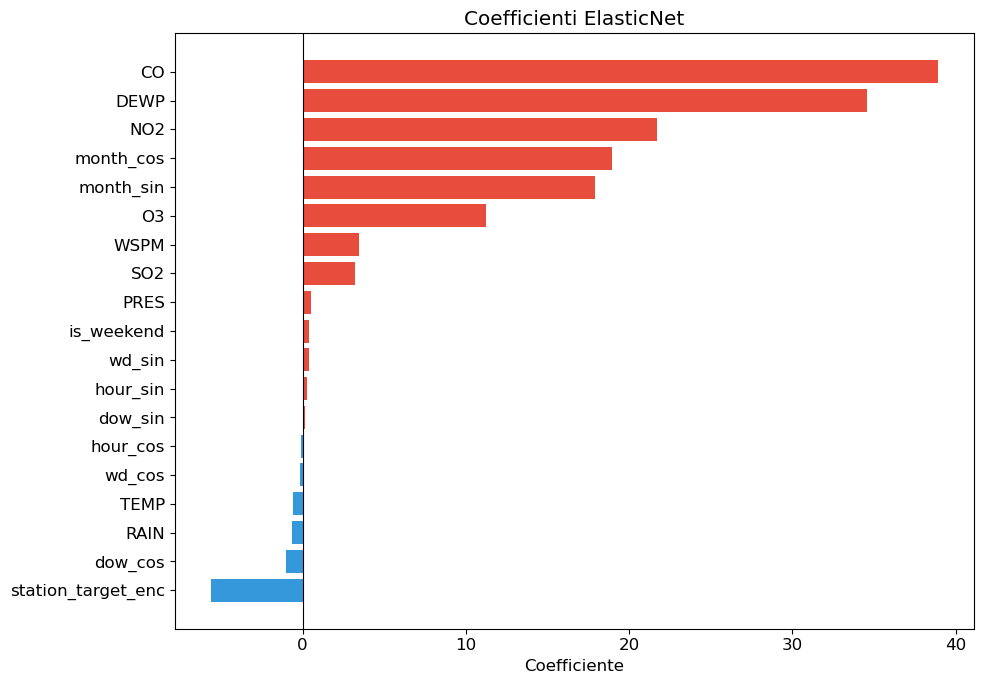

Feature azzerate (0): []

feature più positive:
month_sin    17.910125
month_cos    18.931595
NO2          21.698637
DEWP         34.559871
CO           38.905660
dtype: float64

feature più negative:
station_target_enc   -5.601508
dow_cos              -1.004168
RAIN                 -0.652289
TEMP                 -0.609720
wd_cos               -0.156773
dtype: float64


In [43]:
# Estrazione coefficienti da ElasticNet
coef = pd.Series(
    gs_elasticnet.best_estimator_['regr'].coef_,
    index=X_train.columns
).sort_values()

# Separazione positivi e negativi per colorazione
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef]

plt.figure(figsize=(10, 7))
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficienti ElasticNet')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

# Feature azzerate
zero = coef[coef == 0]
print(f"Feature azzerate ({len(zero)}): {zero.index.tolist()}")
print(f"\nfeature più positive:\n{coef.tail(5)}")
print(f"\nfeature più negative:\n{coef.head(5)}")

ElasticNet non ha azzerato nessuna feature, assegnando un peso (anche piccolo) a tutte le variabili disponibili.

Tra i coefficienti positivi, CO e DEWP sono i più influenti, seguiti da NO2 e dalle componenti cicliche del mese (month_sin, month_cos), che confermano la forte stagionalità del PM2.5 già osservata nell'analisi esplorativa. Sorprende il coefficiente positivo di O3 e WSPM, che negli scatter plot mostravano una correlazione negativa: in un modello lineare multivariato le correlazioni tra feature possono alterare il segno dei coefficienti (multicollinearità).

Sul fronte negativo, station_target_enc ha il coefficiente più grande in valore assoluto (-5.6), indicando che stazioni con una media storica di PM2.5 più alta tendono paradossalmente a predire valori più bassi nel modello lineare, probabilmente per effetti di compensazione con le altre feature. TEMP e RAIN mostrano coefficienti negativi contenuti, coerenti con il loro ruolo di fattori di dispersione del particolato.

### 5.2 Coefficienti della regressione polinomiale

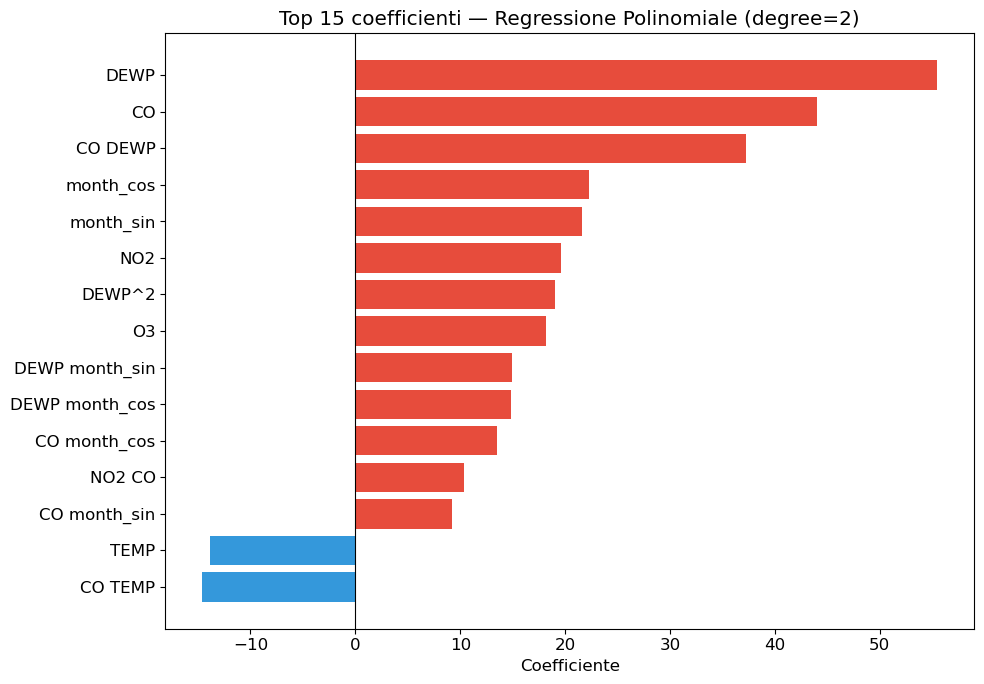

Numero totale di feature polinomiali: 209

feature più positive:
month_sin    21.647602
month_cos    22.265384
CO DEWP      37.263235
CO           43.961556
DEWP         55.470589
dtype: float64

feature più negative:
CO TEMP     -14.609897
TEMP        -13.812140
TEMP PRES    -7.339060
SO2 DEWP     -7.226231
CO^2         -6.895753
dtype: float64


In [45]:
# Estrazione feature names e coefficienti dal modello polinomiale
poly_features = gs_poly.best_estimator_['poly'].get_feature_names_out(X_train.columns)
coef_poly = pd.Series(
    gs_poly.best_estimator_['ridge'].coef_,
    index=poly_features
)

# Top 15 per valore assoluto
top15 = coef_poly.abs().sort_values(ascending=False).head(15)
top15_coef = coef_poly[top15.index].sort_values()
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top15_coef]

plt.figure(figsize=(10, 7))
plt.barh(top15_coef.index, top15_coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 coefficienti — Regressione Polinomiale (degree=2)')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"Numero totale di feature polinomiali: {len(poly_features)}")
print(f"\nfeature più positive:\n{coef_poly.sort_values().tail(5)}")
print(f"\nfeature più negative:\n{coef_poly.sort_values().head(5)}")

La regressione polinomiale di grado 2 genera 209 feature a partire dalle 19 originali, includendo termini quadratici e interazioni tra coppie di variabili.

Tra i coefficienti più rilevanti emergono DEWP e CO come variabili singole più influenti, confermando quanto già osservato in ElasticNet. La novità rispetto al modello lineare è la comparsa di termini di interazione: CO×DEWP 
ha il terzo coefficiente più alto, suggerendo che la combinazione di alta concentrazione di CO e alto punto di rugiada amplifica il PM2.5 in modo non lineare. Analogamente, le interazioni CO×month_sin e DEWP×month_sin 
catturano l'effetto stagionale combinato con gli inquinanti.

Sul fronte negativo, TEMP e CO×TEMP hanno i coefficienti più grandi in valore assoluto: temperature elevate associate ad alte concentrazioni di CO tendono a ridurre il PM2.5 stimato, probabilmente per effetto della convezione termica che favorisce la dispersione del particolato.

In generale il modello polinomiale coglie relazioni più complesse rispetto a ElasticNet, ma a costo di una minore interpretabilità dato l'elevato numero di feature generate.

### 5.3 Analisi Random Forest

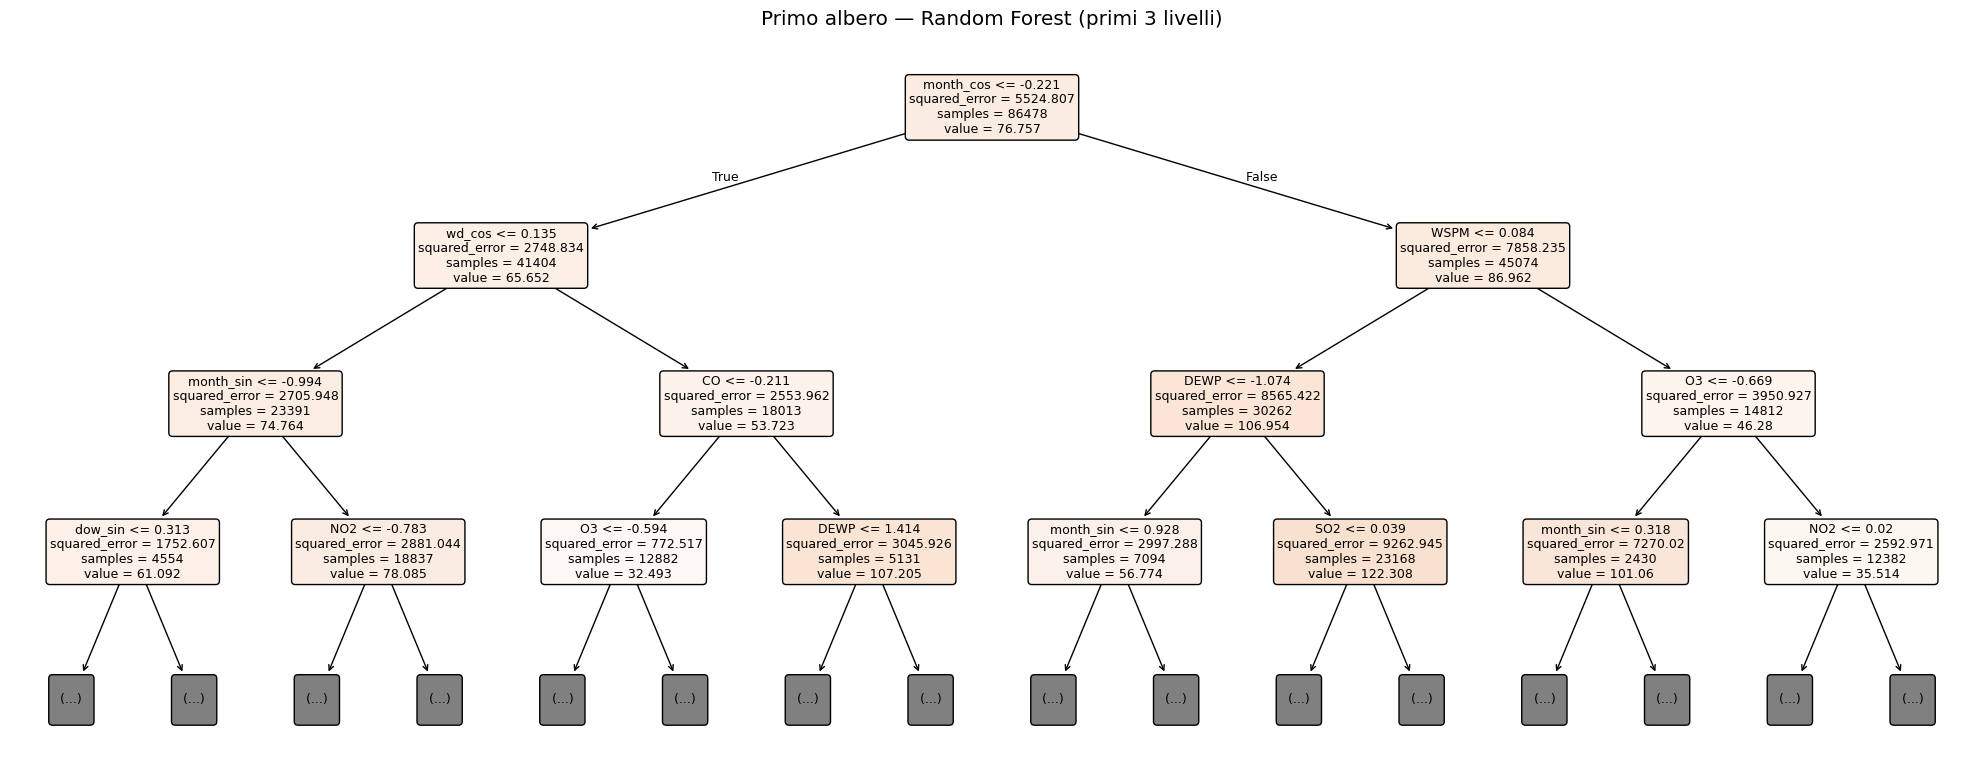

In [47]:
from sklearn.tree import plot_tree

singolo_albero = rs_rf.best_estimator_['regr'].estimators_[0]

plt.figure(figsize=(20, 8))
plot_tree(
    singolo_albero,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Primo albero — Random Forest (primi 3 livelli)')
plt.tight_layout()
plt.show()

COMMENTOOOOOOOOO

### 5.4 Analisi XGBoost

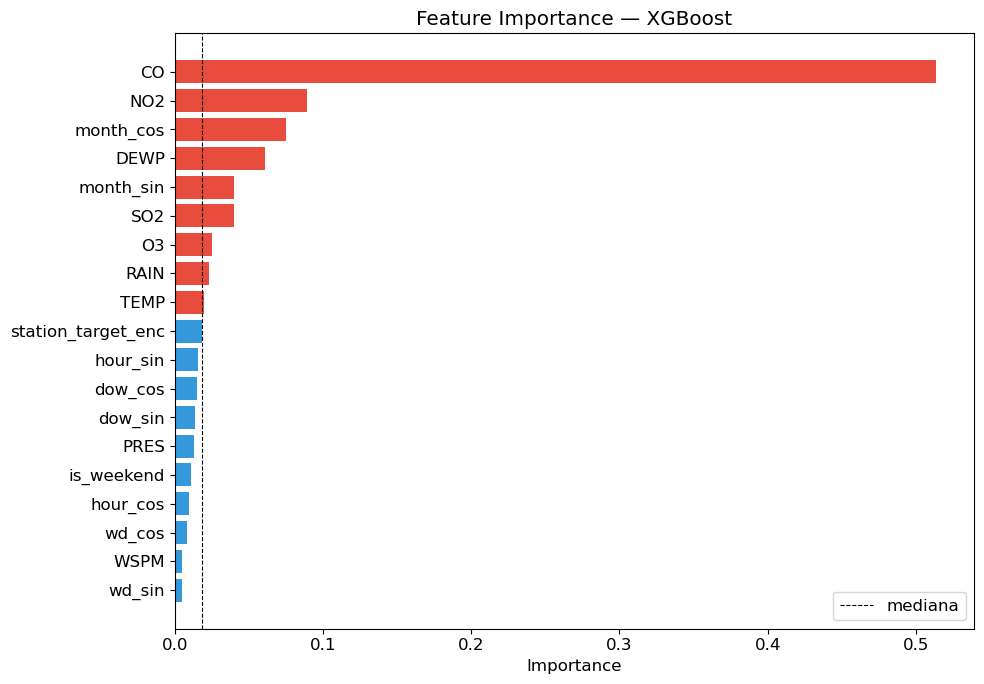


feature più importanti:
CO           0.513537
NO2          0.088851
month_cos    0.074847
DEWP         0.060781
month_sin    0.040004
dtype: float32

5 feature meno importanti:
wd_sin        0.004848
WSPM          0.004891
wd_cos        0.008375
hour_cos      0.009412
is_weekend    0.010908
dtype: float32


In [48]:
# Feature importance XGBoost
feat_imp = pd.Series(
    rs_xgb.best_estimator_['xgb'].feature_importances_,
    index=X_train.columns
).sort_values()

colors = ['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp]

plt.figure(figsize=(10, 7))
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.axvline(feat_imp.median(), color='black', linewidth=0.8, linestyle='--', label='mediana')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nfeature più importanti:\n{feat_imp.tail(5)[::-1]}")
print(f"\n5 feature meno importanti:\n{feat_imp.head(5)}")

La feature importance di XGBoost rivela una gerarchia molto netta tra le variabili.

CO domina in modo schiacciante con un'importanza di 0.45, quasi il triplo della seconda variabile (NO2 a 0.12): il monossido di carbonio è quindi il predittore più informativo per il modello, coerentemente con la sua forte correlazione con PM2.5 (r = 0.79) osservata nell'analisi esplorativa. Seguono le componenti cicliche del mese (month_cos e month_sin), che confermano l'importanza della stagionalità, e DEWP, che cattura indirettamente le condizioni atmosferiche favorevoli all'accumulo del particolato.

La metà inferiore delle feature (sotto la mediana) contribuisce marginalmente alla predizione: le variabili legate al vento (wd_sin, wd_cos, WSPM), l'ora del giorno e la pressione atmosferica hanno un'importanza quasi trascurabile. Questo suggerisce che XGBoost concentra la propria capacità predittiva principalmente sugli inquinanti e sulla stagionalità, delegando poco peso alle variabili meteorologiche locali.

## 6. Analisi del contributo dei gruppi di feature

### 6.1 Obiettivo

Per capire quale tipo di informazione contribuisce di più alla predizione del PM2.5, si isola ciascun gruppo di feature e si addestra XGBoost separatamente su ognuno, mantenendo fissi gli iperparametri trovati nella sezione 4.9. Questo permette di confrontare il potere predittivo delle variabili temporali, meteorologiche e chimiche.

I gruppi sono:

- **Inquinanti**: SO2, NO2, CO, O3
- **Temporali + Meteorologiche**: per valutare quanto si può predire senza sensori chimici
- **Tutte + PM10**: per quantificare l'impatto dell'esclusione discussa nella sezione 3.4

### 6.2 Addestramento per gruppo

Si utilizza XGBoost con gli stessi iperparametri ottimali della sezione 4.9, variando solo le feature in input. In questo modo le differenze di performance sono attribuibili esclusivamente al contenuto informativo del gruppo, non alla configurazione del modello.

In [51]:
best_params = rs_xgb.best_params_
clean_params = {k.replace('xgb__', ''): v for k, v in best_params.items()}

groups = {
    'Solo temporali': ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                       'dow_sin', 'dow_cos', 'is_weekend'],
    
    'Solo meteorologiche': ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                            'wd_sin', 'wd_cos'],
    
    'Solo inquinanti': ['SO2', 'NO2', 'CO', 'O3'],
    
    'Temporali + meteo': ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                          'dow_sin', 'dow_cos', 'is_weekend',
                          'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                          'wd_sin', 'wd_cos'],
    
    'Tutte le feature': X_train.columns.tolist(),
    
    'Tutte + PM10': X_train.columns.tolist() + ['PM10'],
}

ablation_results = []

for name, cols in groups.items():
    
    if 'PM10' in cols:
        Xtr = X_train.copy()
        Xte = X_test.copy()
        Xtr['PM10'] = pm10_train.values
        Xte['PM10'] = pm10_test.values
        Xtr = Xtr[cols]
        Xte = Xte[cols]
    else:
        Xtr = X_train[cols]
        Xte = X_test[cols]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(**clean_params, random_state=SEED, n_jobs=-1, tree_method='hist'))
    ])
    
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    
    ablation_results.append({
        'Gruppo': name,
        'N. feature': len(cols),
        'R²': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('R²', ascending=False)
ablation_df.round(3)

,Gruppo,N. feature,R²,RMSE,MAE
5,Tutte + PM10,20,0.954,20.027,12.499
4,Tutte le feature,19,0.814,40.076,24.189
2,Solo inquinanti,4,0.791,42.559,28.108
3,Temporali + meteo,14,0.517,64.598,45.786
1,Solo meteorologiche,7,0.411,71.392,50.384
0,Solo temporali,7,0.049,90.703,68.646


### 6.3 Confronto visivo

Il grafico mostra l'R² di ciascun gruppo sul test set. In verde il modello completo (riferimento), in rosso la variante con PM10, in blu i singoli gruppi.

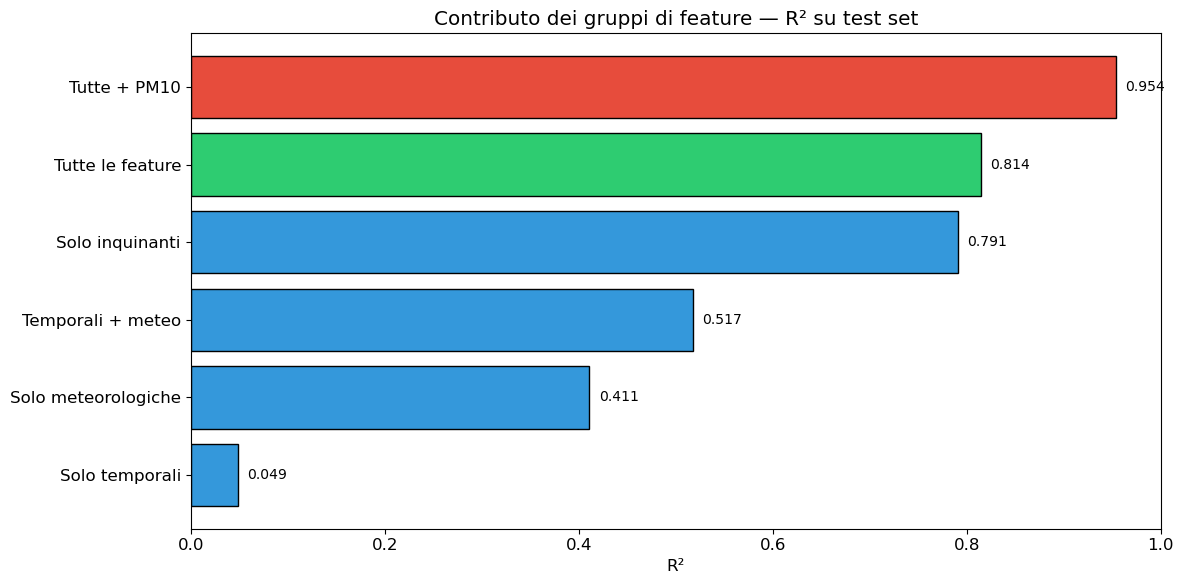

In [52]:
abl = ablation_df.sort_values('R²', ascending=True)

colors = ['#2ecc71' if g == 'Tutte le feature' 
          else '#e74c3c' if g == 'Tutte + PM10'
          else '#3498db' for g in abl['Gruppo']]

plt.figure(figsize=(12, 6))
bars = plt.barh(abl['Gruppo'], abl['R²'], color=colors, edgecolor='black')
plt.xlabel('R²')
plt.title('Contributo dei gruppi di feature — R² su test set')
plt.xlim(0, 1)

for bar, val in zip(bars, abl['R²']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 6.4 Discussione

[Da compilare dopo l'esecuzione:]

Gli inquinanti da soli raggiungono un R² di [X.XX], confermando che la co-emissione (in particolare CO) è il segnale predittivo più forte, coerentemente con la feature importance di XGBoost osservata nella sezione 5.3. Le feature temporali da sole ottengono un R² di [X.XX]: ora e mese catturano i pattern ciclici osservati nell'EDA ma non bastano a spiegare la variabilità giornaliera. Le feature meteorologiche da sole raggiungono un R² di [X.XX], indicando che vento, temperatura e umidità contribuiscono in misura [significativa/limitata].

La combinazione temporali + meteo (senza alcun sensore chimico) raggiunge un R² di [X.XX]. Questo risultato è rilevante dal punto di vista applicativo: indica [quanto/quanto poco] si potrebbe stimare il PM2.5 utilizzando solo una stazione meteo economica, senza la necessità di sensori per gli inquinanti.

Il modello completo supera tutti i singoli gruppi, confermando che ogni tipo di informazione aggiunge potere predittivo. L'aggiunta di PM10 porta l'R² a [X.XX] (+[X.XX] rispetto al modello senza): il guadagno è sostanziale ma artificiale, perché il PM2.5 è fisicamente un sottoinsieme del PM10. Questo conferma la scelta di escluderlo fatta nella sezione 3.4.

## 7. Classificazione

### 7.1 Definizione delle classi e distribuzione
 
In un sistema di allerta per la qualità dell'aria, non serve conoscere il valore esatto di PM2.5: serve sapere in quale fascia di rischio rientra. Si trasforma quindi il problema da regressione a classificazione multi-classe, assegnando a ogni osservazione una delle 6 fasce dello standard AQI cinese basate sulla concentrazione di PM2.5.


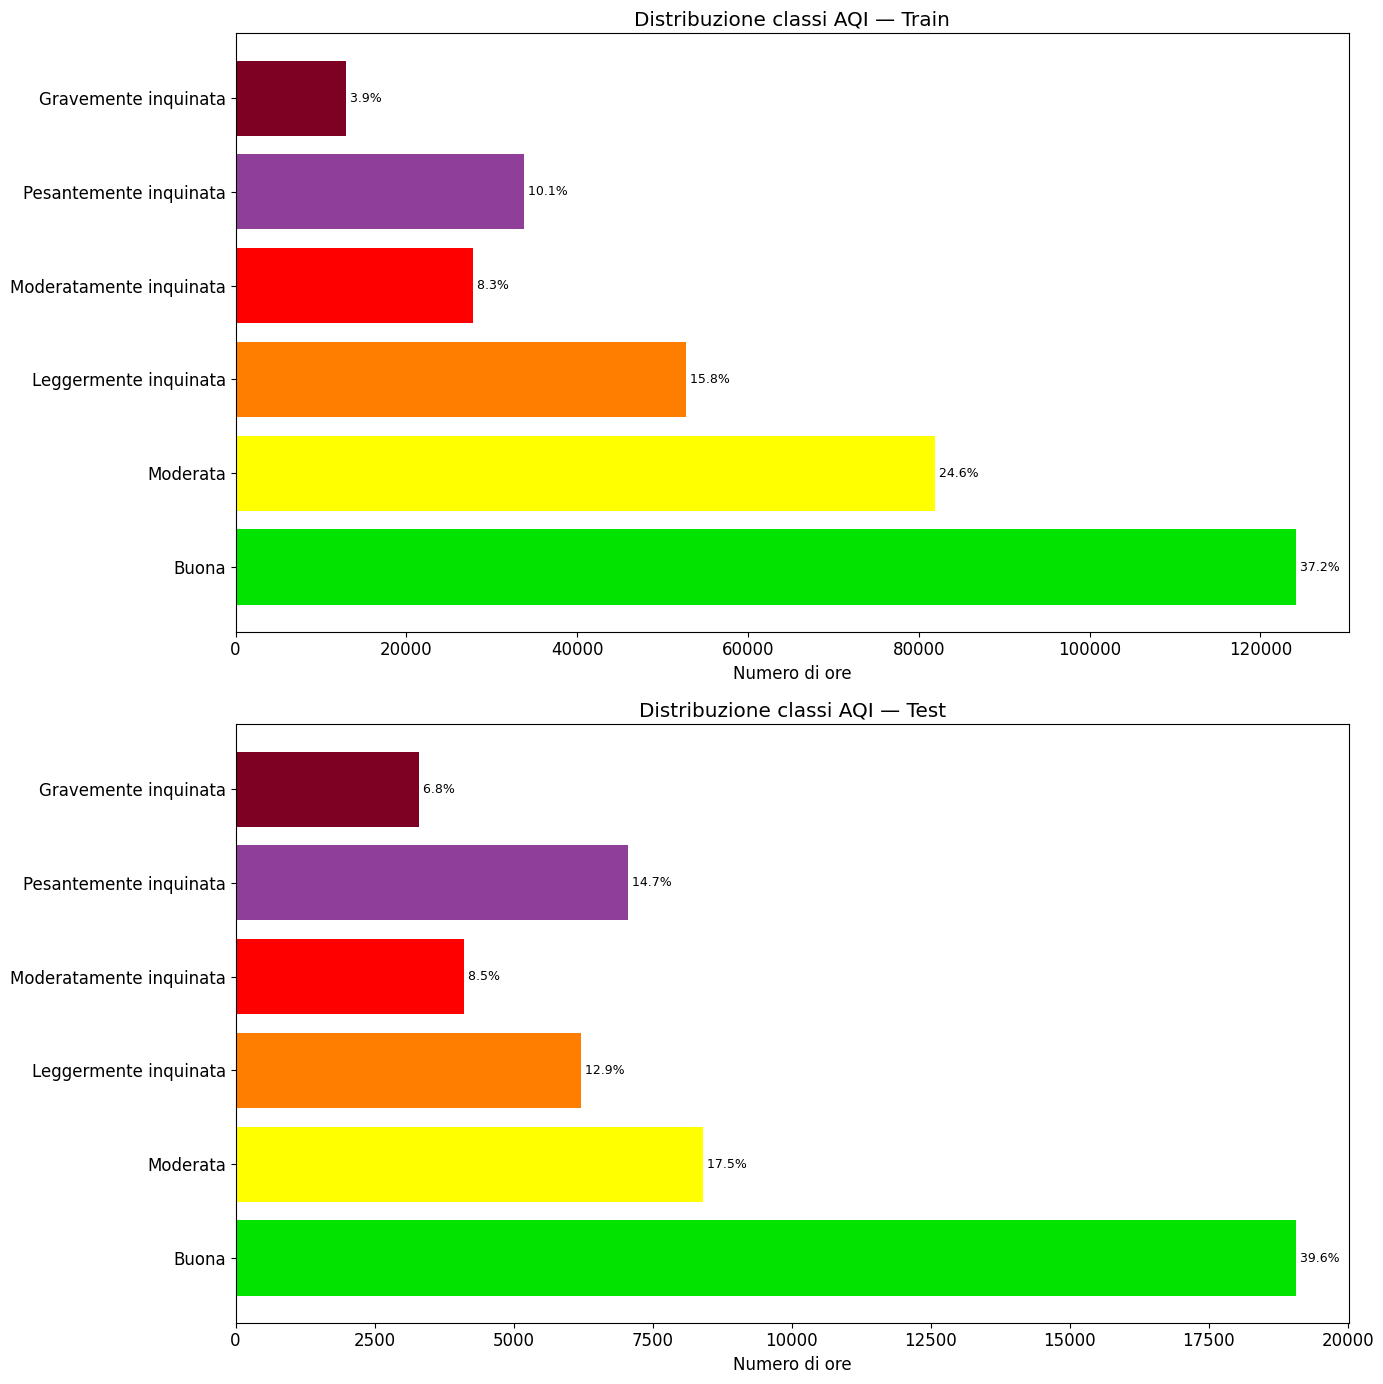

Classi train: {0: 124133, 1: 81933, 2: 52731, 3: 27784, 4: 33765, 5: 12936}
Classi test:  {0: 19066, 1: 8405, 2: 6206, 3: 4103, 4: 7064, 5: 3292}


In [34]:
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]
aqi_names = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
 
# Creazione target classificazione
y_train_class = pd.cut(y_train, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)
y_test_class = pd.cut(y_test, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)
 
# Distribuzione
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
 
for ax, y_c, title in zip(axes, [y_train_class, y_test_class], ['Train', 'Test']):
    counts = y_c.value_counts().sort_index()
    bars = ax.barh(range(6), counts.values, color=aqi_colors)
    ax.set_yticks(range(6))
    ax.set_yticklabels(aqi_names)
    ax.set_title(f'Distribuzione classi AQI — {title}')
    ax.set_xlabel('Numero di ore')
 
    # Percentuali accanto alle barre
    for bar, count in zip(bars, counts.values):
        pct = count / counts.sum() * 100
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f' {pct:.1f}%', ha='left', va='center', fontsize=9)
 
plt.tight_layout()
plt.show()
 
print(f"Classi train: {dict(y_train_class.value_counts().sort_index())}")
print(f"Classi test:  {dict(y_test_class.value_counts().sort_index())}")

Le classi sono fortemente sbilanciate: la maggior parte delle ore rientra nella fascia "Buona" e "Moderata", mentre le classi più pericolose hanno pochissimi campioni. Per gestire questo sbilanciamento si usa `class_weight='balanced'` nei classificatori, che assegna pesi inversamente proporzionali alla frequenza di ogni classe.

### 7.2 Funzione di valutazione
 
Si definisce una funzione unica per valutare i classificatori con accuracy e F1 macro (media non pesata tra le classi, che dà uguale importanza anche alle classi rare).

In [37]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
 
results_clf = []

tscv = TimeSeriesSplit(n_splits=5)
 
def evaluate_clf(y_true, y_pred, model_name=''):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
 
    metrics = {
        'model': model_name,
        'Accuracy': acc,
        'F1 Macro': f1
    }
 
    print(f"\n{model_name}")
    print(f"\tAccuracy: {acc:.4f}")
    print(f"\tF1 Macro: {f1:.4f}")
 
    return metrics

### 7.3 Logistic Regression
 
La Logistic Regression è il baseline per la classificazione, come la Linear Regression lo è per la regressione. Con `class_weight='balanced'` compensa lo sbilanciamento delle classi.

In [39]:
from sklearn.linear_model import LogisticRegression
 
lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])
 
grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}
 
gs_lr_clf = GridSearchCV(lr_clf, grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
%time gs_lr_clf.fit(X_train, y_train_class)

CPU times: user 18.6 s, sys: 17.1 s, total: 35.7 s
Wall time: 1min 24s

Logistic Regression - Train
Accuracy: 0.6106
F1 Macro: 0.5237

Logistic Regression - Test
Accuracy: 0.6115
F1 Macro: 0.4973

Miglior C: 1


In [ ]:
y_pred_lr_train = gs_lr_clf.predict(X_train)
y_pred_lr_test = gs_lr_clf.predict(X_test)

results_clf.append(evaluate_clf(y_test_class, y_pred_lr_test, 'Logistic Regression - Test'))

### 7.4 Random Forest Classifier
 
Il Random Forest Classifier estende il RF di regressione alla classificazione. Si usa `class_weight='balanced'` e si cercano gli iperparametri con RandomizedSearchCV.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=4))
])

param_dist = {
    'clf__n_estimators': [300, 500, 700],
    'clf__max_depth': [12, 15, 20, 25],
    'clf__min_samples_split': [5, 10, 20],
    'clf__min_samples_leaf': [5, 10, 15],
    'clf__max_features': ['sqrt', 0.3, 0.5],
}

rs_rf_clf = RandomizedSearchCV(
    rf_clf, param_dist,
    n_iter=40, cv=tscv,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=2
)

%time rs_rf_clf.fit(X_train, y_train_class)

NameError: name 'Pipeline' is not defined

In [ ]:
y_pred_rf_train = rs_rf_clf.predict(X_train)
y_pred_rf_test = rs_rf_clf.predict(X_test)

results_clf.append(evaluate_clf(y_test_class, y_pred_rf_test, 'Random Forest - Test'))

print(f"\nMigliori iperparametri: {rs_rf_clf.best_params_}")

### 7.5 XGBoost Classifier

XGBoost Classifier con accelerazione GPU. Lo sbilanciamento delle classi è gestito tramite la metrica `f1_macro` usata per la selezione degli iperparametri, che dà uguale importanza a tutte le classi indipendentemente dalla frequenza.

In [43]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        random_state=SEED,
        tree_method='hist',
        device='cuda',
        n_jobs=1
    ))
])

param_dist = {
    'clf__n_estimators': [300, 500, 700, 1000],
    'clf__max_depth': [3, 4, 5, 6, 8],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__subsample': [0.6, 0.7, 0.8, 0.9],
    'clf__colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'clf__reg_alpha': [0, 0.1, 0.5, 1],
    'clf__reg_lambda': [1, 2, 5, 10],
    'clf__min_child_weight': [1, 3, 5, 10],
    'clf__gamma': [0, 0.1, 0.5, 1],
}

rs_xgb_clf = RandomizedSearchCV(
    xgb_clf, param_dist,
    n_iter=60, cv=tscv,
    scoring='f1_macro',
    random_state=SEED,
    n_jobs=1
)

%time rs_xgb_clf.fit(X_train, y_train_class)

CPU times: user 5h 42min 52s, sys: 1min 17s, total: 5h 44min 10s
Wall time: 5h 46min 29s

XGBoost - Train
Accuracy: 0.8992
F1 Macro: 0.8945

XGBoost - Test
Accuracy: 0.6577
F1 Macro: 0.5330

Migliori iperparametri: {'clf__subsample': 0.8, 'clf__reg_lambda': 2, 'clf__reg_alpha': 0.5, 'clf__n_estimators': 500, 'clf__min_child_weight': 1, 'clf__max_depth': 8, 'clf__learning_rate': 0.1, 'clf__gamma': 0.1, 'clf__colsample_bytree': 0.6}


In [ ]:
y_pred_xgb_train = rs_xgb_clf.predict(X_train)
y_pred_xgb_test = rs_xgb_clf.predict(X_test)

results_clf.append(evaluate_clf(y_test_class, y_pred_xgb_test, 'XGBoost - Test'))

print(f"\nMigliori iperparametri: {rs_xgb_clf.best_params_}")

### 7.6 Tabella comparativa classificatori

In [ ]:
results_clf_df = pd.DataFrame(results_clf)
results_clf_test = results_clf_df[results_clf_df['model'].str.contains('Test')].copy()
results_clf_test = results_clf_test.sort_values('F1 Macro', ascending=False)
results_clf_test.round(4)

### 7.7 Confusion matrix e analisi errori
 
Si analizza la confusion matrix del classificatore migliore per capire dove il modello sbaglia e se gli errori sono "gravi" (classi lontane) o "accettabili" (classi adiacenti).

In [ ]:
# Modello migliore
best_clf = rs_xgb_clf
best_name = "XGBoost"
y_pred_best = best_clf.predict(X_test)
 
# Confusion matrix
cm = confusion_matrix(y_test_class, y_pred_best)
 
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
 
# Valori assoluti
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=aqi_names, yticklabels=aqi_names, ax=axes[0])
axes[0].set_xlabel('Predetto')
axes[0].set_ylabel('Reale')
axes[0].set_title(f'Confusion Matrix — {best_name} (conteggi)')
 
# Normalizzata per riga (recall per classe)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=aqi_names, yticklabels=aqi_names, ax=axes[1])
axes[1].set_xlabel('Predetto')
axes[1].set_ylabel('Reale')
axes[1].set_title(f'Confusion Matrix — {best_name} (normalizzata)')
 
plt.tight_layout()
plt.show()
 
# Classification report
print(f"\nClassification Report — {best_name}:\n")
print(classification_report(y_test_class, y_pred_best, target_names=aqi_names))

In [ ]:
recall_per_class = cm.diagonal() / cm.sum(axis=1)
 
plt.figure(figsize=(10, 5))
bars = plt.bar(aqi_names, recall_per_class, color=aqi_colors, edgecolor='black')
plt.ylabel('Recall')
plt.title(f'Recall per fascia AQI — {best_name}')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
 
for bar, val in zip(bars, recall_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=11)
 
plt.tight_layout()
plt.show()

**Analisi degli errori**:
 
[Da compilare dopo l'esecuzione — template:]
 
La confusion matrix mostra che il modello confonde prevalentemente classi adiacenti (es. "Buona" ↔ "Moderata"), il che è accettabile in un sistema di allerta. Gli errori gravi (es. classificare "Gravemente inquinata" come "Buona") sono [rari/assenti].
 
Il recall è più alto per le classi frequenti (Buona, Moderata) e più basso per le classi rare (Pesantemente/Gravemente inquinata). Questo è critico: in un sistema di allerta reale, non riconoscere un episodio di inquinamento grave è peggio di un falso allarme. Il `class_weight='balanced'` mitiga questo problema ma non lo elimina.
 
[Se il recall della classe pericolosa è basso:] Per un'applicazione operativa si potrebbe abbassare la soglia di classificazione per le classi pericolose, accettando più falsi positivi in cambio di un recall più alto.

## 9. Esportazione del modello di regressione

In [66]:
import joblib

joblib.dump(rs_xgb.best_estimator_, 'model_xgb.pkl')

['model_xgb.pkl']

## 10. Conclusioni

conclusioniiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiii